# CNN for Image Classification on CIFAR-10

## Aim
To design, implement, train, and evaluate a Convolutional Neural Network (CNN) using TensorFlow/Keras for multi-class image classification on the CIFAR-10 dataset, and to study the effect of CNN hyperparameters, feature maps, and pooling strategies on model performance.

## Objectives
1. Understand fundamental CNN building blocks: convolution, activation, pooling, flattening, and fully connected layers.
2. Study how convolution kernels extract features such as edges, textures, and patterns.
3. Study the effect of hyperparameters: kernel size, stride, padding, number of filters, optimizer, batch size, epochs.
4. Visualize intermediate feature maps to understand hierarchical feature learning.
5. Compare pooling strategies (Max Pooling vs Average Pooling).
6. Analyze the number of trainable parameters in convolutional layers.
7. Train and evaluate a CNN on CIFAR-10 using accuracy, precision, recall, F1-score, confusion matrix, and classification report.

## Dataset
**CIFAR-10**: 60,000 32x32 color images in 10 classes (6000 images per class) — airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. 50,000 training images and 10,000 test images.


## 1. Setup: Fonts and Imports

In [1]:
!wget -q -O "TimesNewRoman.ttf" "https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf"

import matplotlib
import matplotlib.font_manager as font_manager
import shutil as _shutil
_shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)

font_manager.fontManager.addfont("TimesNewRoman.ttf")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


## 2. Global Plot Formatting (600 DPI, Times New Roman, EPS export)

In [2]:
# Global Plot Formatting

plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

plt.rcParams['font.family'] = 'Times New Roman'

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

plt.rcParams['legend.fontsize'] = 15

sns.set_style("whitegrid")
sns.set_context("notebook")

label_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

title_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

legend_style = {
    'family': 'Times New Roman',
    'weight': 'bold',
    'size': 15
}

def format_axis_ticks(current_axis):

    for tick_label in (
        current_axis.get_xticklabels()
        + current_axis.get_yticklabels()
    ):
        tick_label.set_fontweight('bold')
        tick_label.set_fontname('Times New Roman')

def format_legend_text(current_legend):

    if current_legend is not None:

        for legend_entry in current_legend.get_texts():
            legend_entry.set_fontweight('bold')
            legend_entry.set_fontname('Times New Roman')

        legend_title = current_legend.get_title()
        if legend_title is not None:
            legend_title.set_fontweight('bold')
            legend_title.set_fontname('Times New Roman')


## 3. Load and Explore the CIFAR-10 Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape :", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape      :", x_test.shape)
print("Test labels shape    :", y_test.shape)
print("Pixel value range    : [{}, {}]".format(x_train.min(), x_train.max()))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 450s 3us/step
Training data shape : (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape      : (10000, 32, 32, 3)
Test labels shape    : (10000, 1)
Pixel value range    : [0, 255]


### 3.1 Class Distribution

/tmp/ipykernel_880/301048454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  dist_axis = sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")


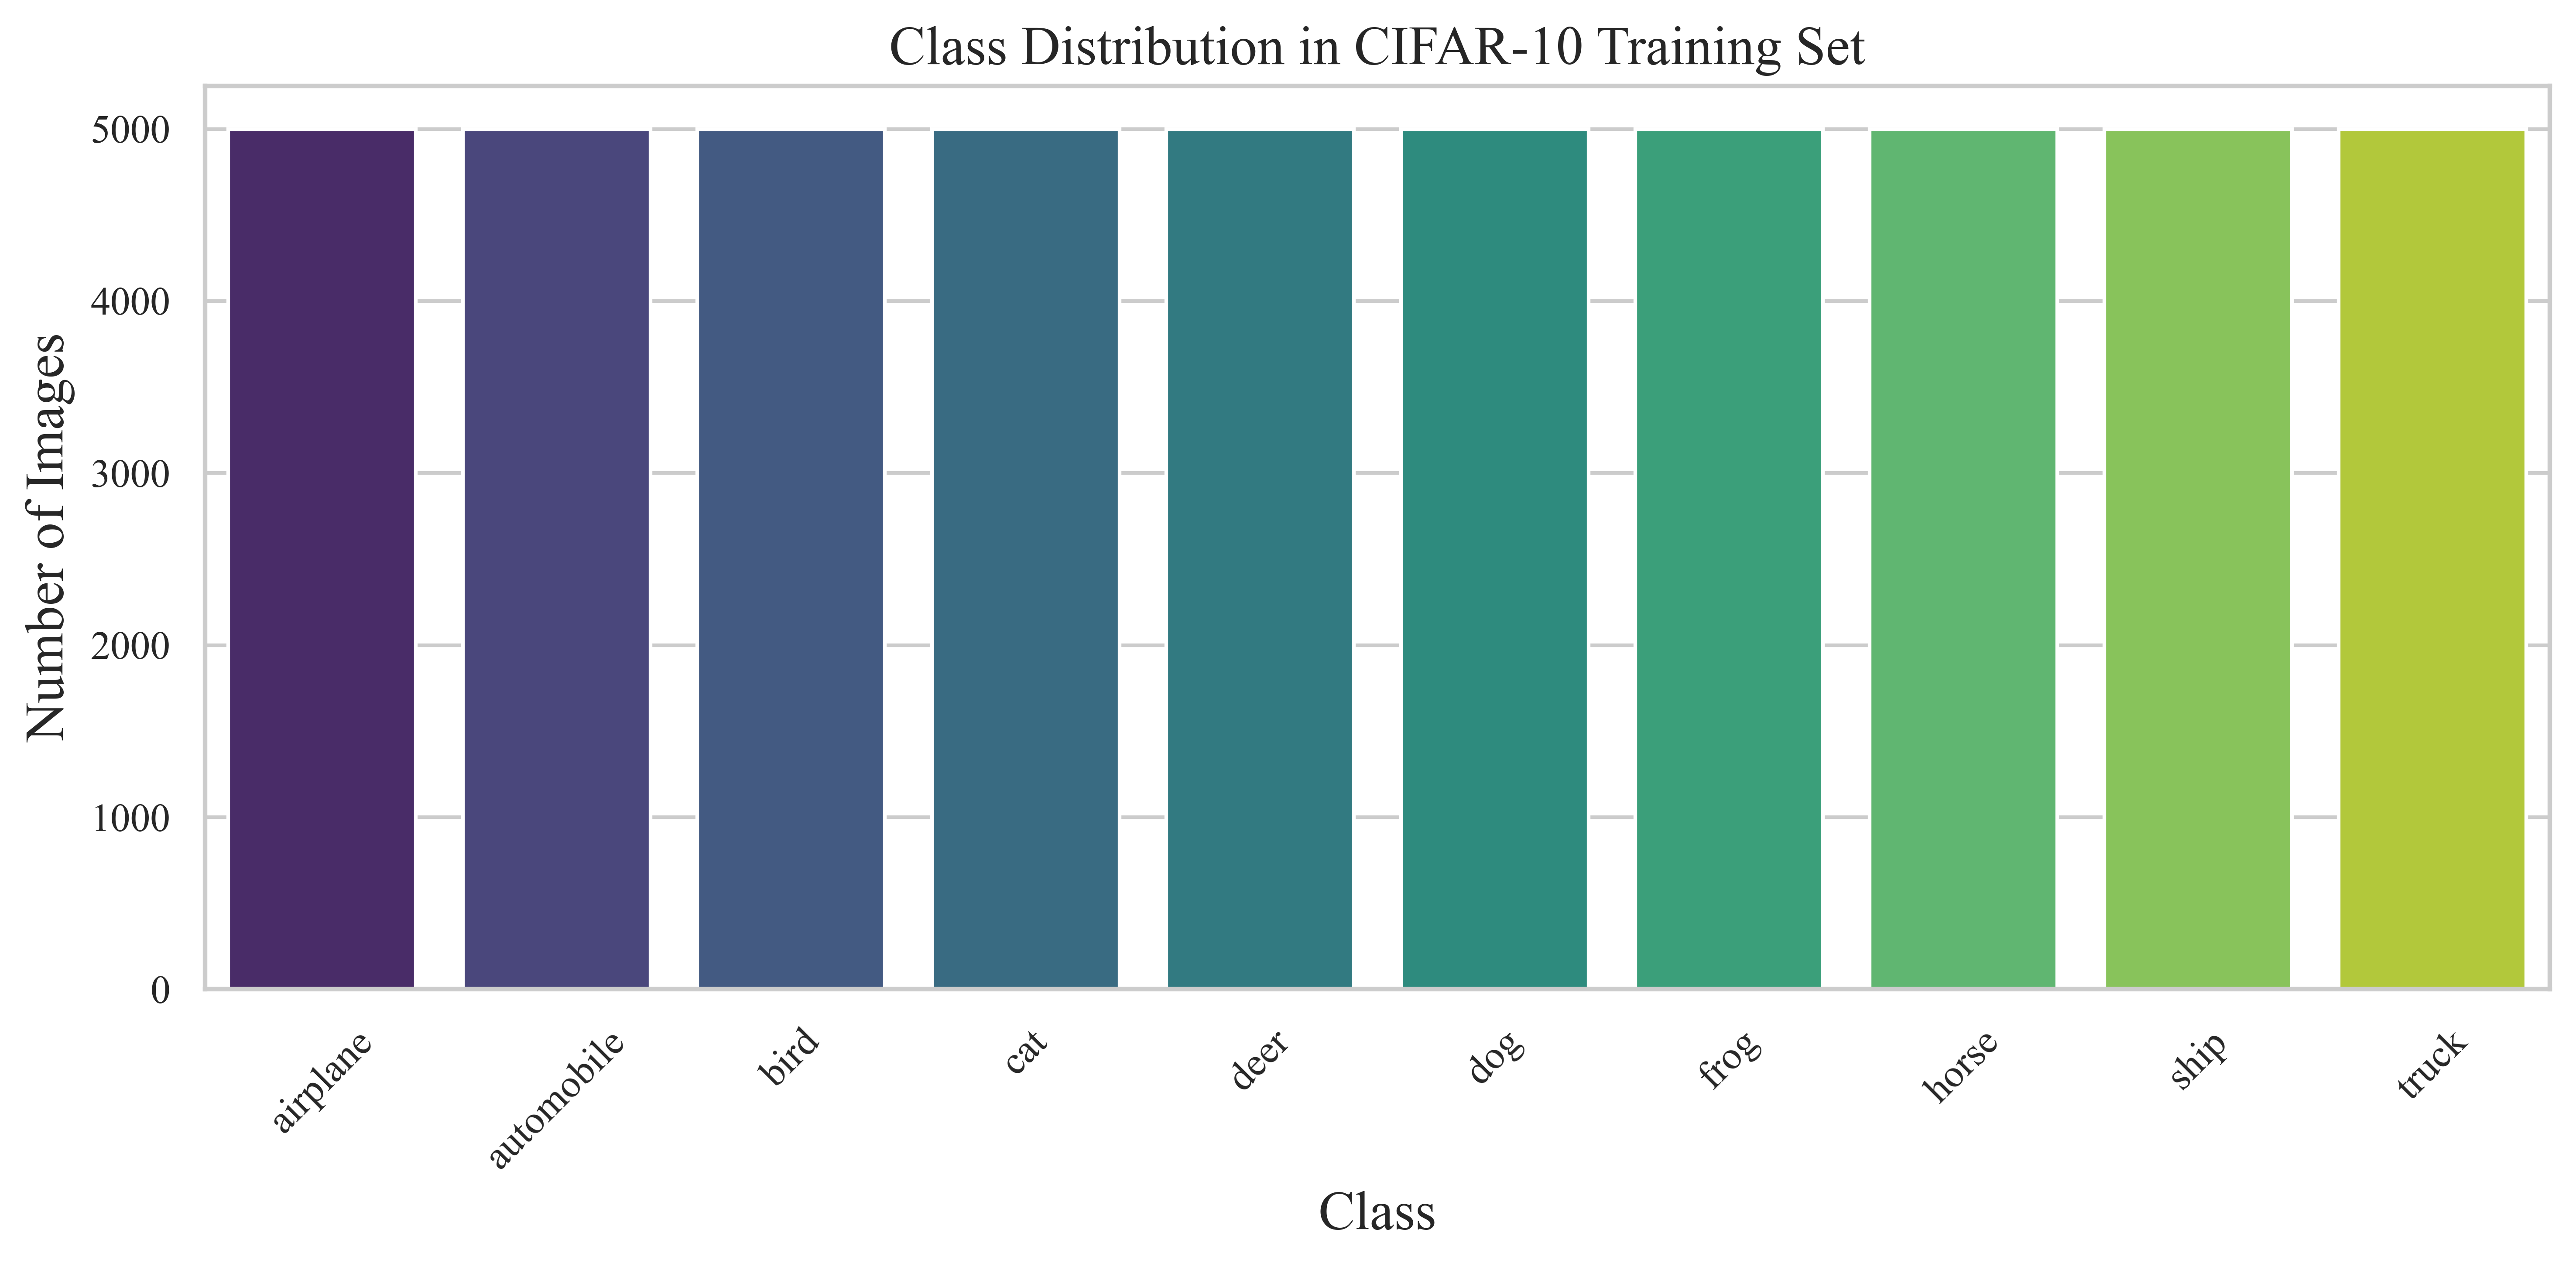

airplane    : 5000 images
automobile  : 5000 images
bird        : 5000 images
cat         : 5000 images
deer        : 5000 images
dog         : 5000 images
frog        : 5000 images
horse       : 5000 images
ship        : 5000 images
truck       : 5000 images


In [4]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
dist_axis = sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")

dist_axis.set_title("Class Distribution in CIFAR-10 Training Set", **title_style)
dist_axis.set_xlabel("Class", **label_style)
dist_axis.set_ylabel("Number of Images", **label_style)
plt.xticks(rotation=45)

format_axis_ticks(dist_axis)

plt.tight_layout()

plt.savefig(
    "class_distribution.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

for i, c in zip(unique, counts):
    print(f"{class_names[i]:12s}: {c} images")


### 3.2 Sample Images from Each Class

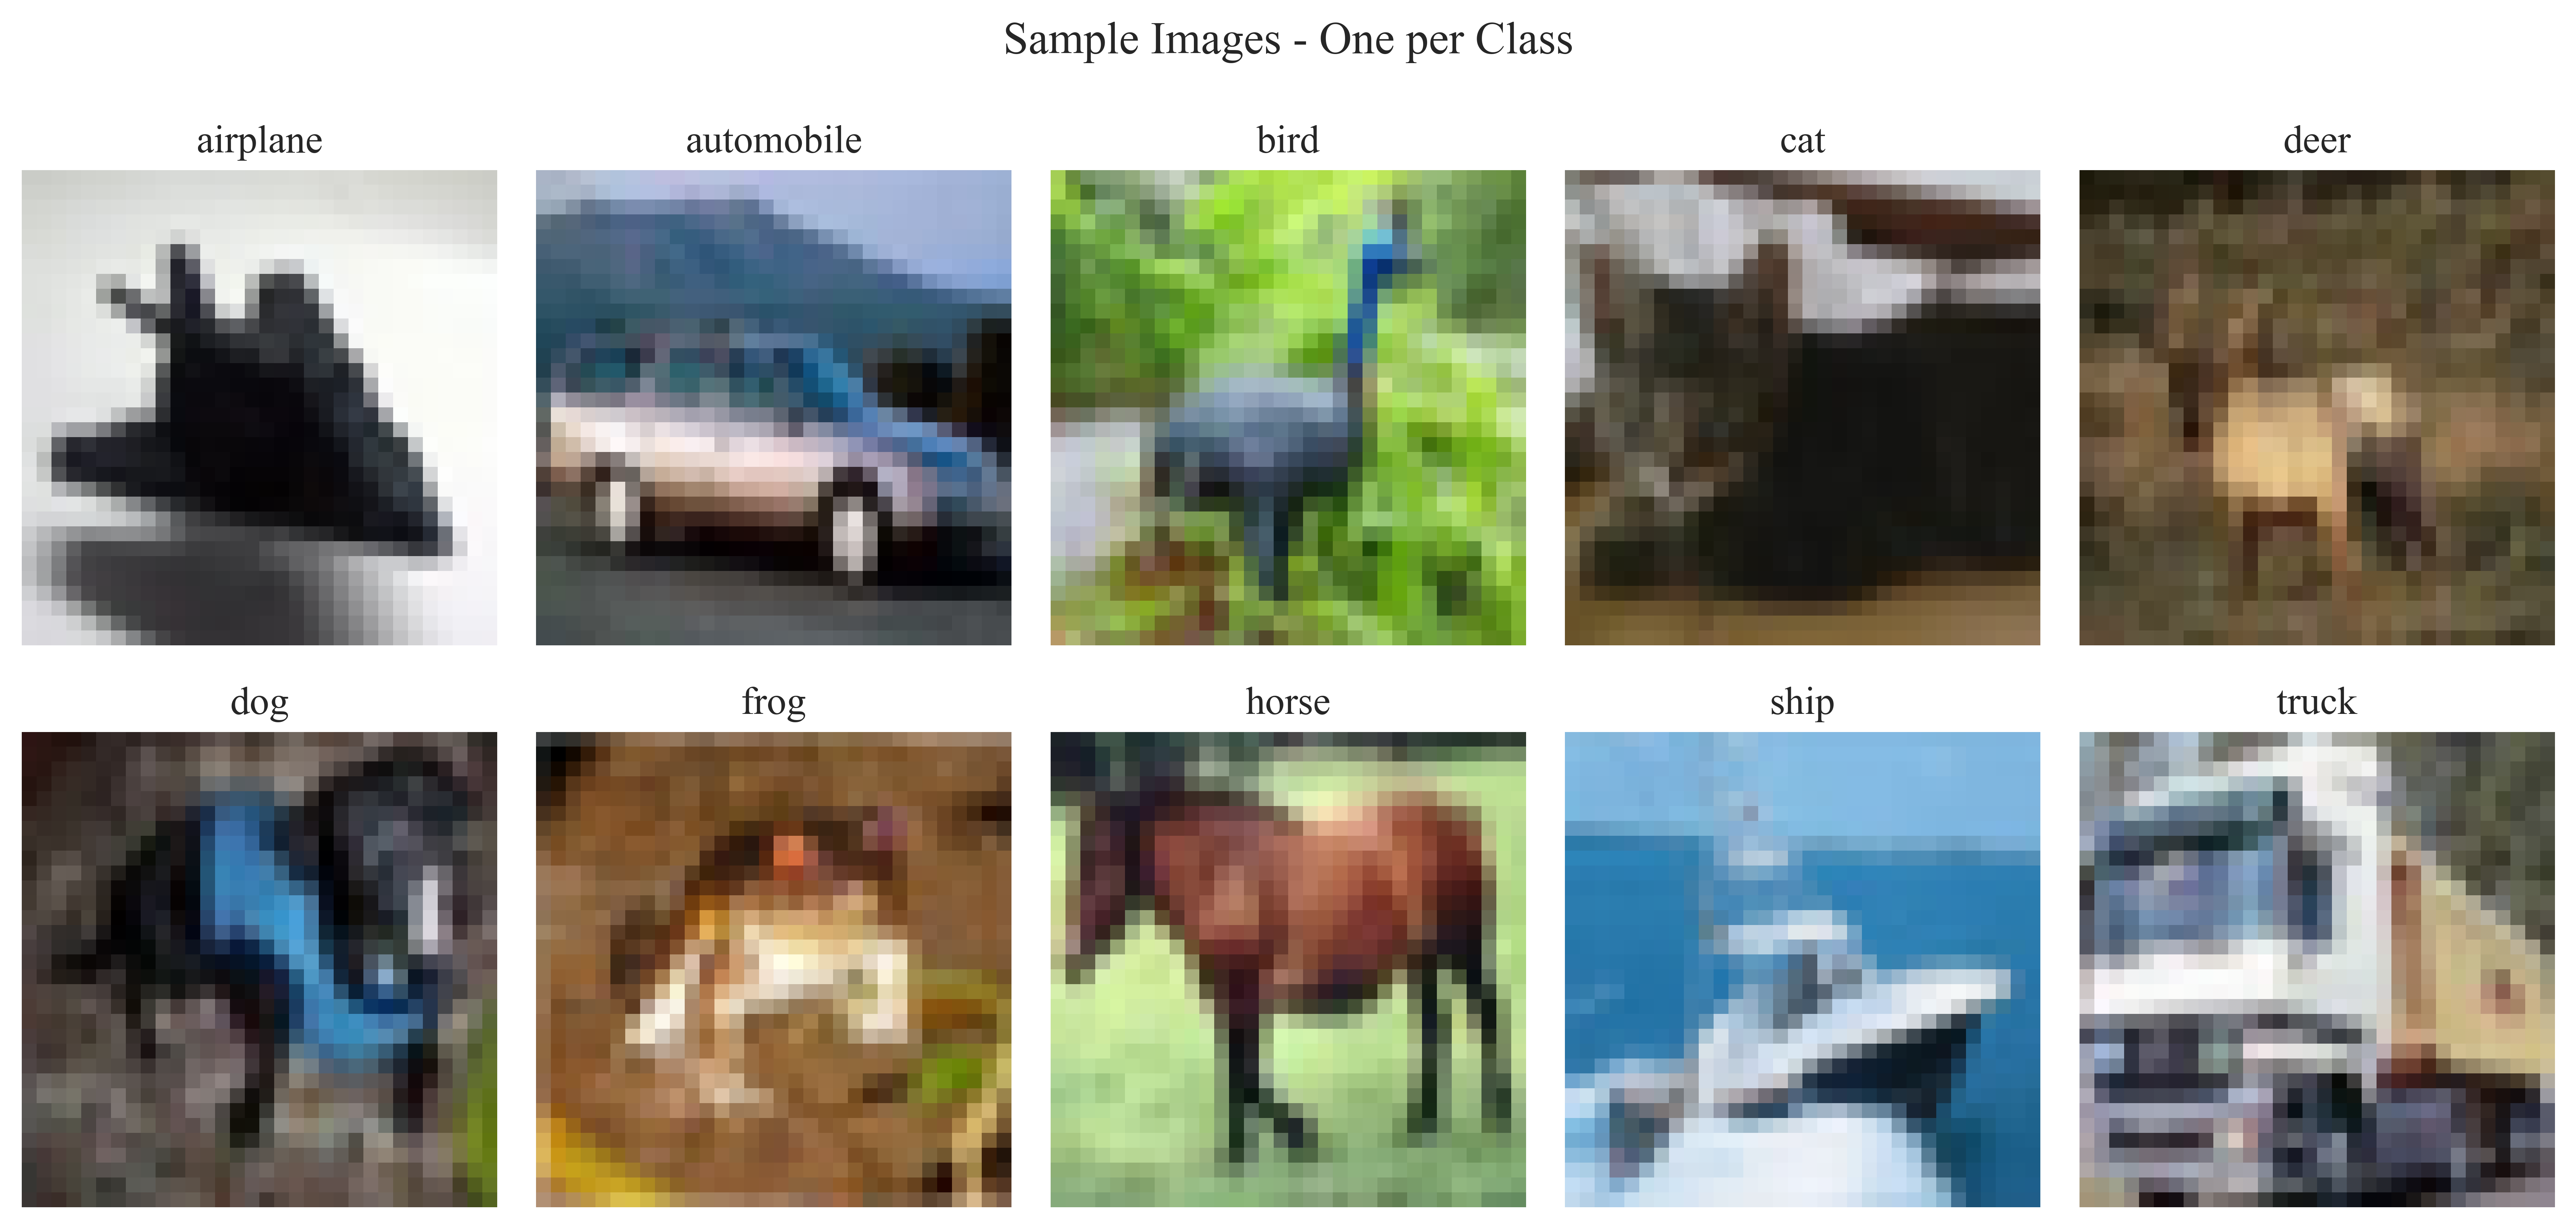

In [5]:
sample_fig, sample_axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    current_axis = sample_axes.flatten()[i]
    current_axis.imshow(x_train[idx])
    current_axis.set_title(class_names[i], fontsize=13, fontweight='bold', fontname='Times New Roman')
    current_axis.axis('off')

sample_fig.suptitle("Sample Images - One per Class", fontsize=15, fontweight='bold', fontname='Times New Roman')
plt.tight_layout()

plt.savefig(
    "sample_images.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 4. Data Preprocessing

- Normalize pixel values to the range [0, 1].
- One-hot encode the class labels for multi-class classification.
- Split a validation set from the training data.


In [6]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Create a validation split
val_size = 5000
x_val = x_train[:val_size]
y_val_cat = y_train_cat[:val_size]
x_train_final = x_train[val_size:]
y_train_final = y_train_cat[val_size:]

print("Final training set :", x_train_final.shape)
print("Validation set     :", x_val.shape)
print("Test set            :", x_test.shape)


Final training set : (45000, 32, 32, 3)
Validation set     : (5000, 32, 32, 3)
Test set            : (10000, 32, 32, 3)


## 5. CNN Building Blocks — Conceptual Overview

| Layer | Purpose |
|---|---|
| **Convolutional Layer** | Applies learnable kernels/filters that slide over the image to extract local features such as edges, textures, and patterns. Key hyperparameters: number of filters, kernel size, stride, padding. |
| **Activation Function (ReLU)** | Introduces non-linearity, allowing the network to learn complex patterns. |
| **Pooling Layer** | Downsamples feature maps (Max/Average Pooling), reducing spatial dimensions and computation while retaining important features and providing translation invariance. |
| **Batch Normalization** | Stabilizes and accelerates training by normalizing layer activations. |
| **Flatten Layer** | Converts 2D feature maps into a 1D vector for the fully connected layers. |
| **Fully Connected (Dense) Layer** | Combines extracted features to perform final classification. |
| **Dropout** | Regularization technique to reduce overfitting by randomly deactivating neurons during training. |

### Effect of Key Hyperparameters
- **Kernel size**: Larger kernels capture broader spatial context but increase parameters and computation; smaller kernels (e.g., 3x3) capture fine local detail and are computationally efficient.
- **Stride**: Larger stride reduces the output feature map size faster and reduces computation, but may skip fine detail.
- **Padding**: `'same'` padding preserves spatial dimensions; `'valid'` padding shrinks the feature map after every convolution.
- **Number of filters**: More filters allow the network to learn a richer set of features but increase the number of trainable parameters.
- **Optimizer**: Adam typically converges faster than plain SGD; RMSprop and SGD with momentum are common alternatives.
- **Batch size**: Smaller batches give noisier but often better-generalizing updates; larger batches are more computationally efficient per step but need more memory.
- **Epochs**: Too few epochs underfit; too many can overfit without regularization/early stopping.


## 6. CNN Architecture Design

We build a CNN with three convolutional blocks (Conv2D + BatchNorm + ReLU + MaxPooling), followed by flattening and fully connected layers with dropout for regularization. The model is built using the Keras **Functional API** (an explicit `Input` layer) so that intermediate layer outputs can be reliably extracted later for feature map visualization.


In [7]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape, name='input_layer')

    # Block 1
    x = layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1),
                       padding='same', activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool1')(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv3')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv4')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool2')(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(128, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv5')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool3')(x)
    x = layers.Dropout(0.4)(x)

    # Fully Connected Layers
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, activation='relu', name='dense1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="CIFAR10_CNN")
    return model

model = build_cnn()
model.summary()


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,57

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

### 6.1 Analyzing Trainable Parameters of Convolutional Layers

In [8]:
print(f"{'Layer':15s} {'Output Shape':20s} {'Params':>12s}")
print("-" * 50)
total_conv_params = 0
for layer in model.layers:
    if 'conv' in layer.name:
        params = layer.count_params()
        total_conv_params += params
        print(f"{layer.name:15s} {str(tuple(layer.output.shape)):20s} {params:12,d}")

print("-" * 50)
print(f"Total Convolutional Layer Parameters: {total_conv_params:,d}")
print(f"Total Model Parameters              : {model.count_params():,d}")

# Manual verification for conv1: (kernel_h * kernel_w * in_channels + 1) * num_filters
kh, kw, in_ch, filters = 3, 3, 3, 32
manual_params = (kh * kw * in_ch + 1) * filters
print(f"\nManual check for 'conv1': (3*3*3 + 1) * 32 = {manual_params}")


Layer           Output Shape               Params
--------------------------------------------------
conv1           (None, 32, 32, 32)            896
conv2           (None, 32, 32, 32)          9,248
conv3           (None, 16, 16, 64)         18,496
conv4           (None, 16, 16, 64)         36,928
conv5           (None, 8, 8, 128)          73,856
--------------------------------------------------
Total Convolutional Layer Parameters: 139,424
Total Model Parameters              : 668,842

Manual check for 'conv1': (3*3*3 + 1) * 32 = 896


## 7. Compile the Model

We use the **Adam** optimizer, **categorical cross-entropy** loss (suitable for multi-class, one-hot encoded labels), and track **accuracy** as the metric.


In [9]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## 8. Train the CNN

Key hyperparameters used: `batch_size=64`, `epochs=20`. Data augmentation is applied to improve generalization.


In [10]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train_final)

BATCH_SIZE = 64
EPOCHS = 30

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

lr_schedule = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    datagen.flow(x_train_final, y_train_final, batch_size=BATCH_SIZE),
    validation_data=(x_val, y_val_cat),
    epochs=EPOCHS,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.3870 - loss: 1.8149 - val_accuracy: 0.5204 - val_loss: 1.3652 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.5330 - loss: 1.2993 - val_accuracy: 0.6280 - val_loss: 1.0617 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.5995 - loss: 1.1232 - val_accuracy: 0.6614 - val_loss: 0.9742 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6376 - loss: 1.0266 - val_accuracy: 0.6566 - val_loss: 1.0036 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6606 - loss: 0.9605 - val_accuracy: 0.7190 - val_loss: 0.8153 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.6792 - loss: 0.9167 - val_accuracy: 0.6676 - val_loss: 1.0295 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6916 - l

## 9. Training and Validation Accuracy/Loss Curves

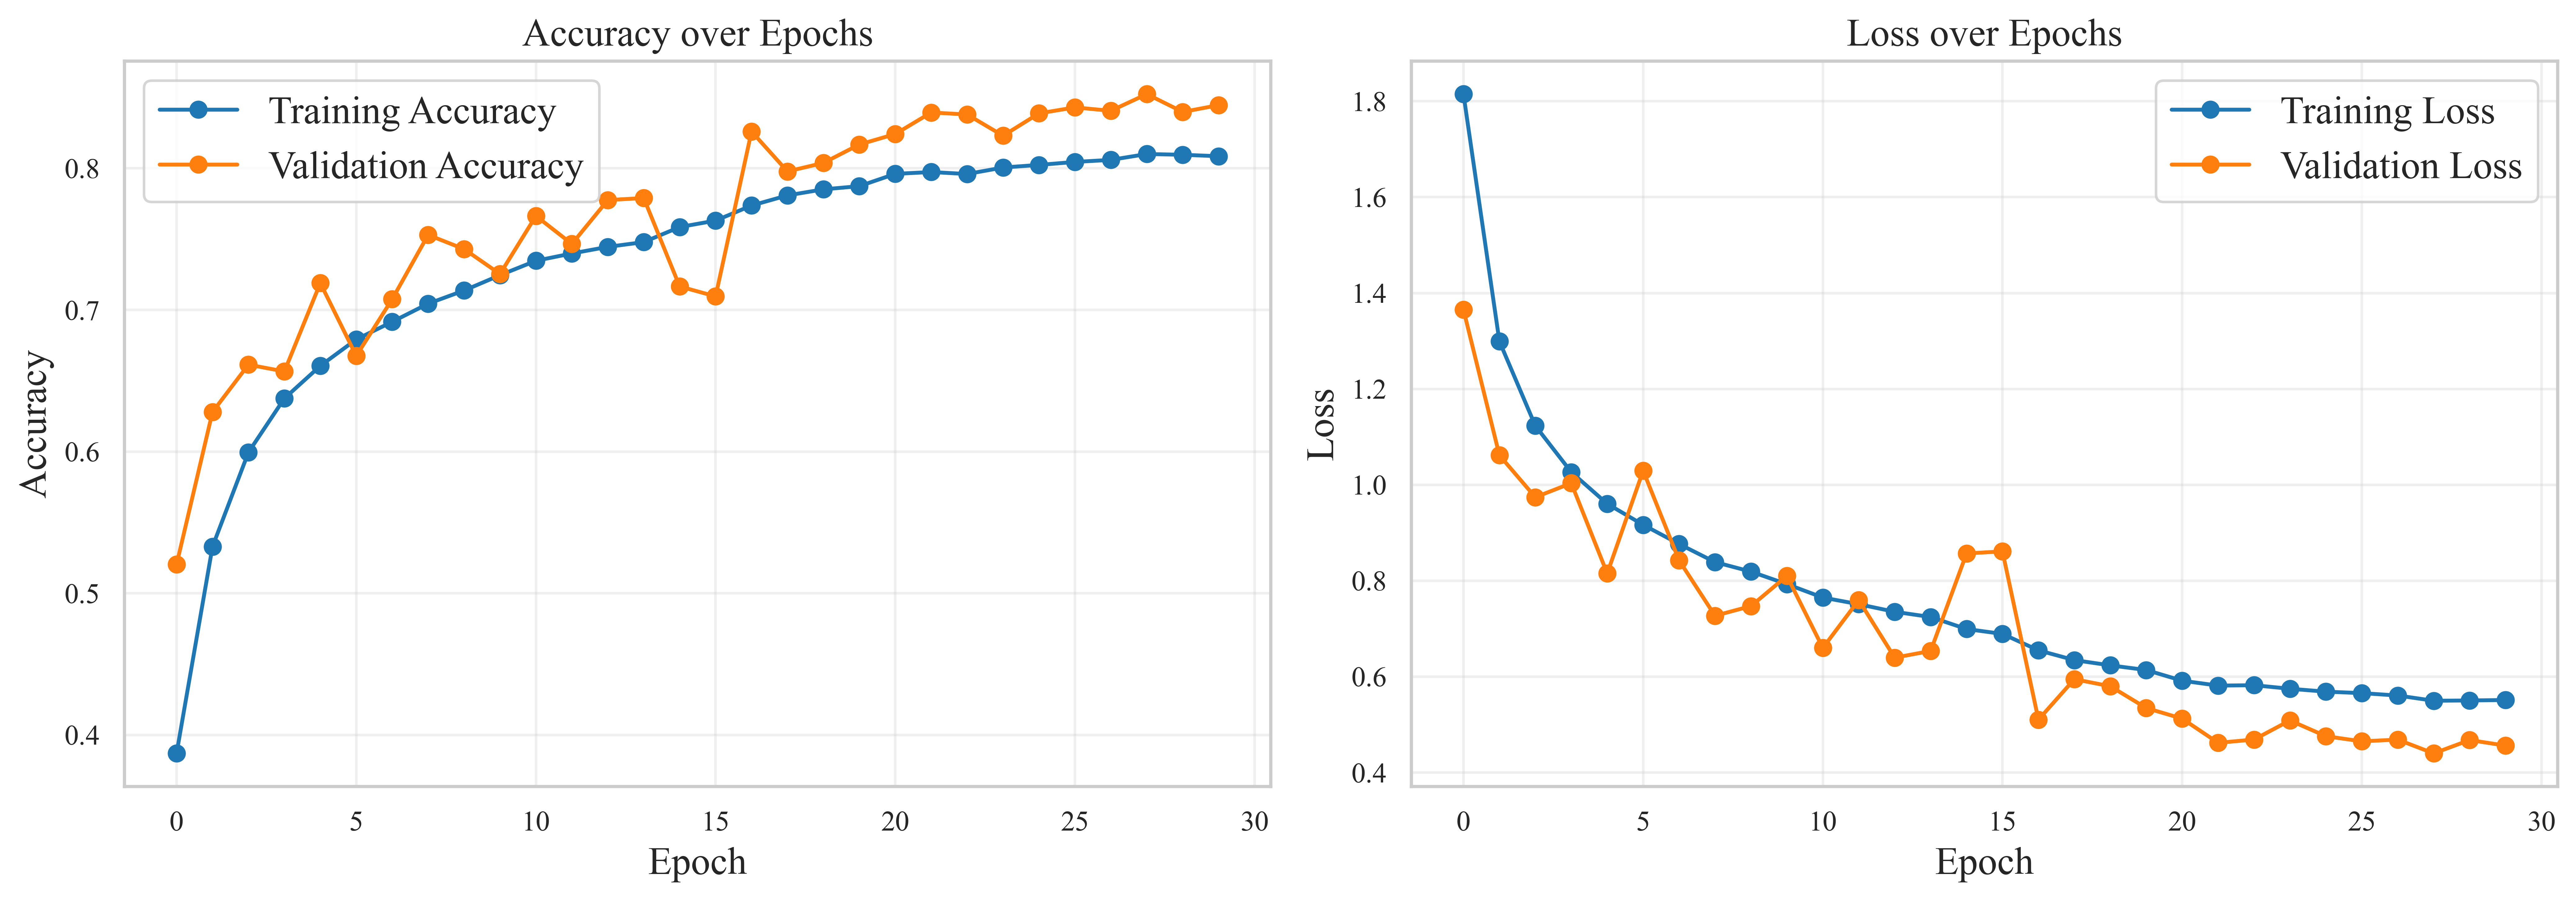

In [11]:
curve_fig, curve_axes = plt.subplots(1, 2, figsize=(14, 5))

acc_axis = curve_axes[0]
acc_axis.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
acc_axis.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
acc_axis.set_title('Accuracy over Epochs', **title_style)
acc_axis.set_xlabel('Epoch', **label_style)
acc_axis.set_ylabel('Accuracy', **label_style)
acc_legend = acc_axis.legend(prop=legend_style)
format_axis_ticks(acc_axis)
format_legend_text(acc_legend)
acc_axis.grid(alpha=0.3)

loss_axis = curve_axes[1]
loss_axis.plot(history.history['loss'], label='Training Loss', marker='o')
loss_axis.plot(history.history['val_loss'], label='Validation Loss', marker='o')
loss_axis.set_title('Loss over Epochs', **title_style)
loss_axis.set_xlabel('Epoch', **label_style)
loss_axis.set_ylabel('Loss', **label_style)
loss_legend = loss_axis.legend(prop=legend_style)
format_axis_ticks(loss_axis)
format_legend_text(loss_legend)
loss_axis.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_curves.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 10. Model Evaluation on Test Set

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()


Test Loss    : 0.4890
Test Accuracy: 0.8314


### 10.1 Precision, Recall, F1-Score

In [13]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


Accuracy : 0.8314
Precision: 0.8369
Recall   : 0.8314
F1-Score : 0.8289


### 10.2 Classification Report

In [14]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

    airplane       0.84      0.85      0.85      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.85      0.70      0.77      1000
         cat       0.79      0.60      0.68      1000
        deer       0.81      0.83      0.82      1000
         dog       0.84      0.69      0.76      1000
        frog       0.68      0.96      0.79      1000
       horse       0.86      0.88      0.87      1000
        ship       0.92      0.92      0.92      1000
       truck       0.86      0.94      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



### 10.3 Confusion Matrix

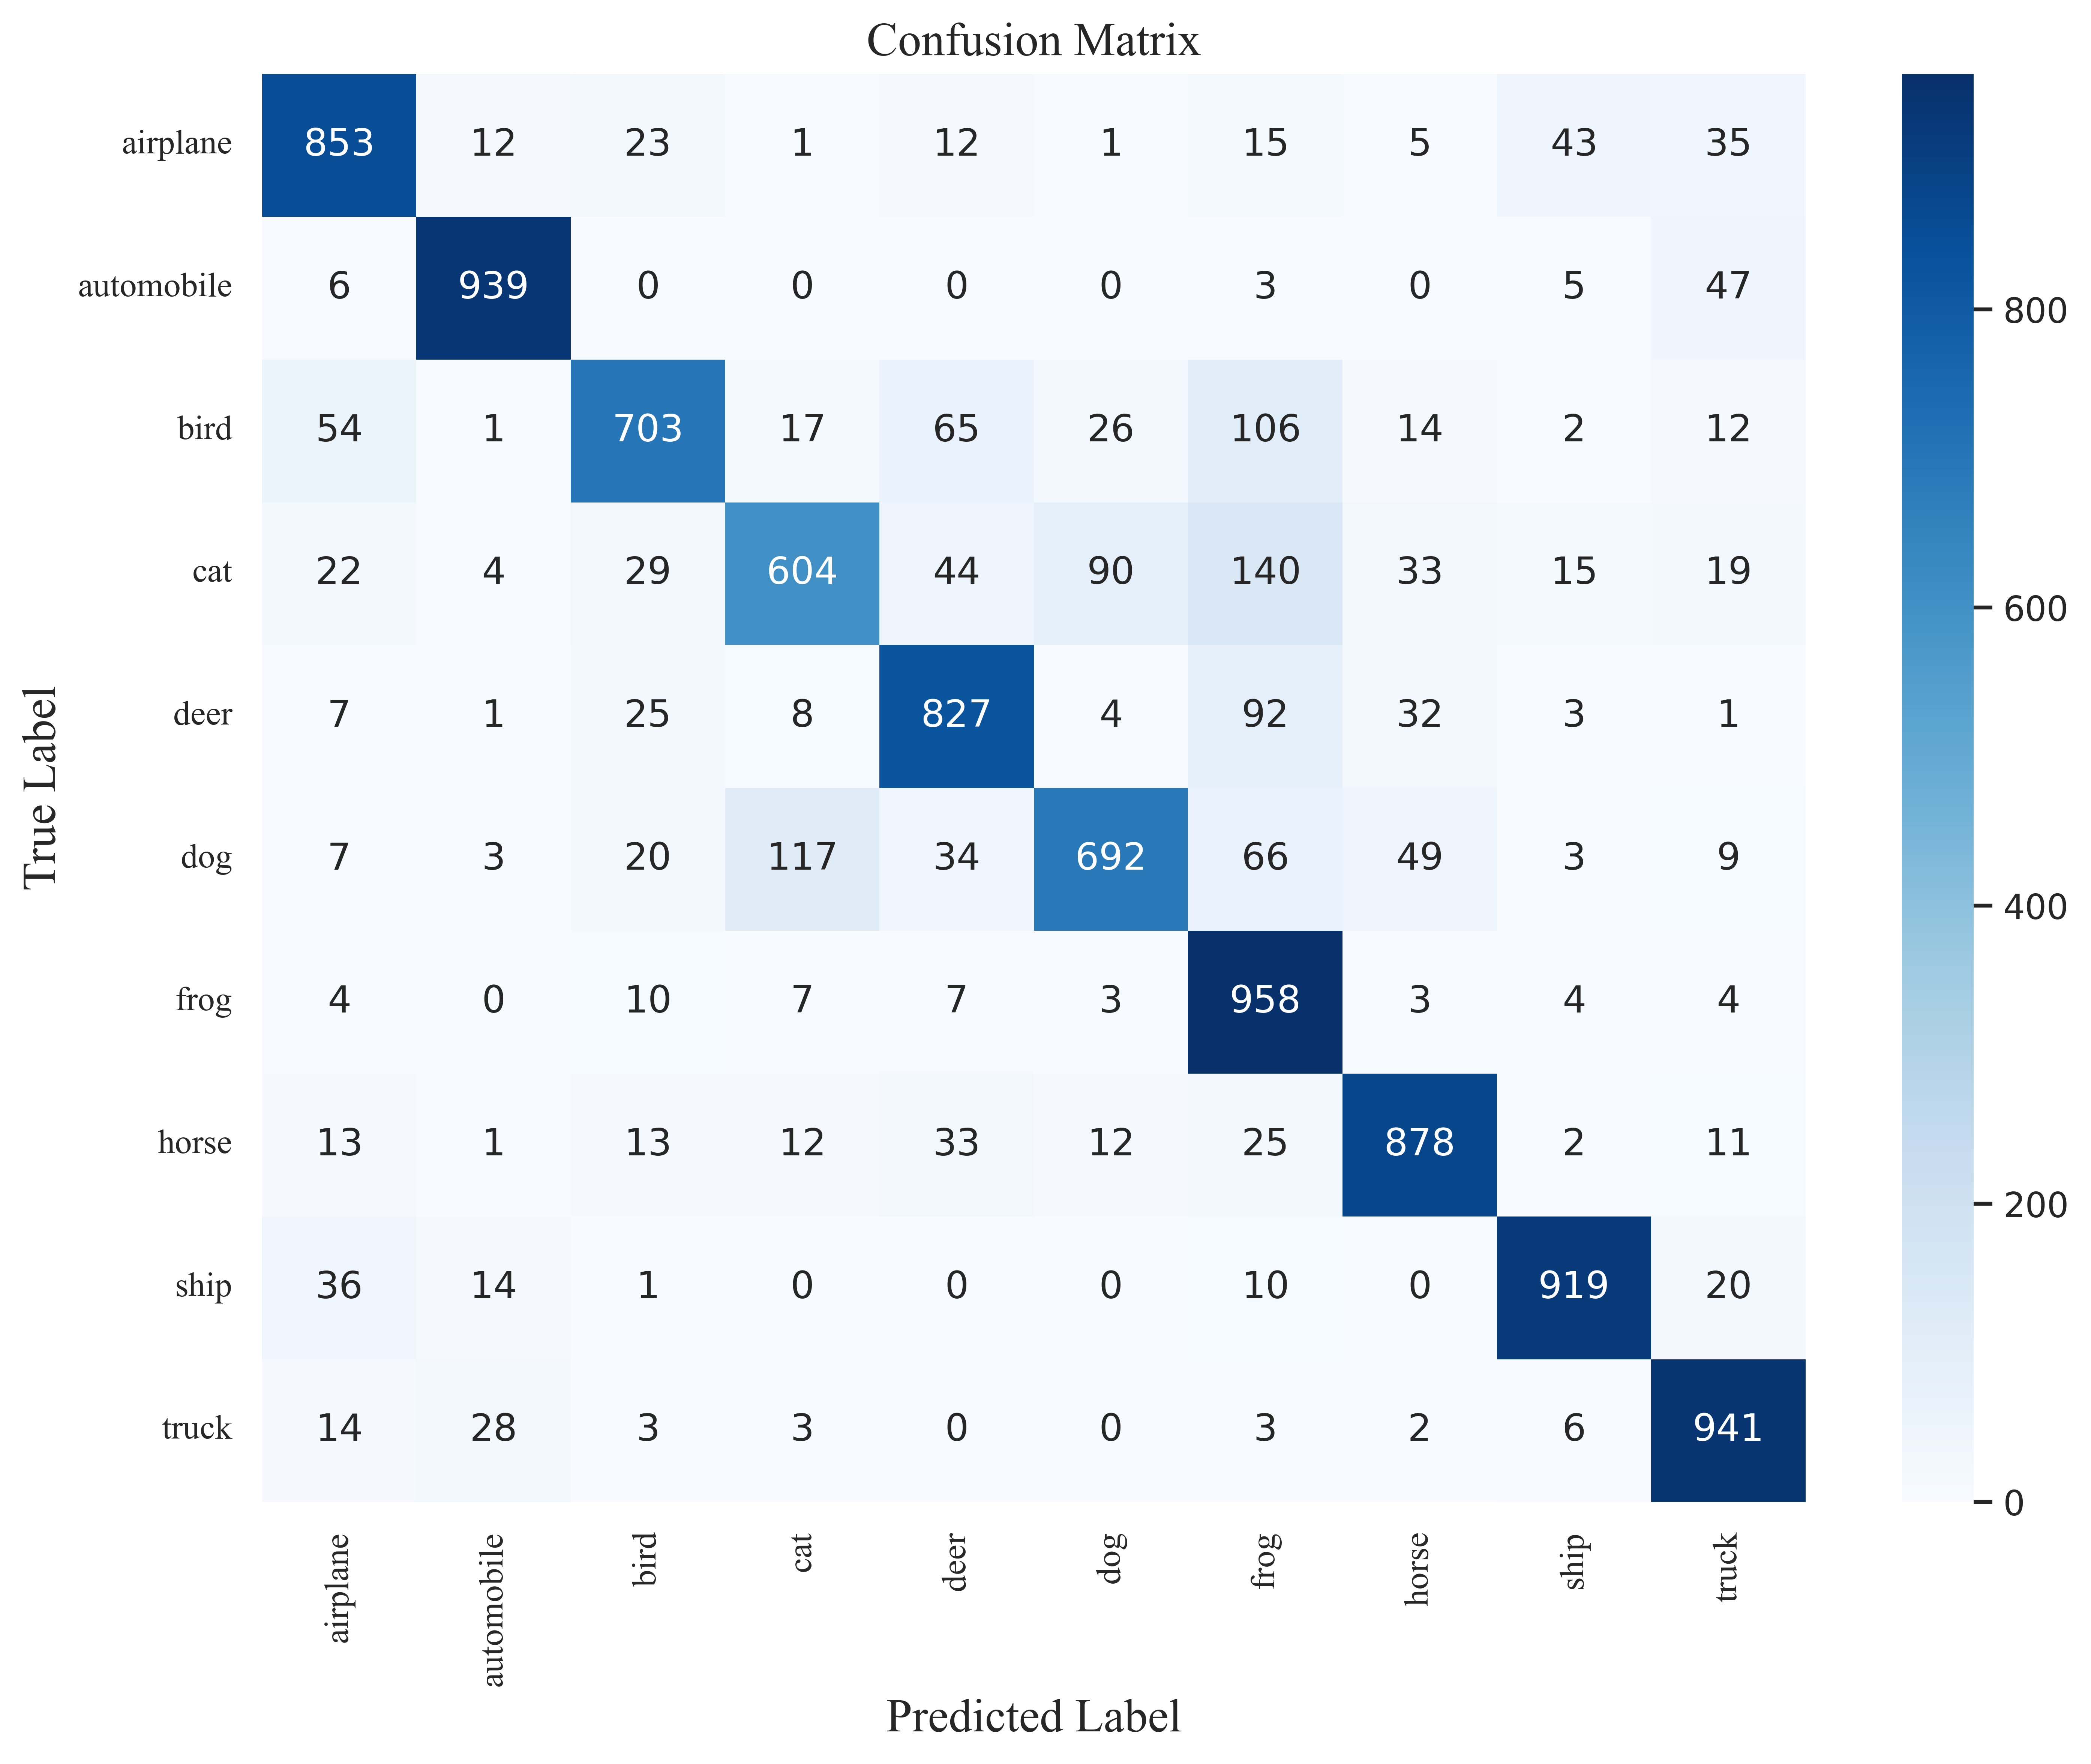

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

cm_axis = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=class_names, yticklabels=class_names)

cm_axis.set_title('Confusion Matrix', **title_style)
cm_axis.set_xlabel('Predicted Label', **label_style)
cm_axis.set_ylabel('True Label', **label_style)

format_axis_ticks(cm_axis)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


### 10.4 Sample Predictions

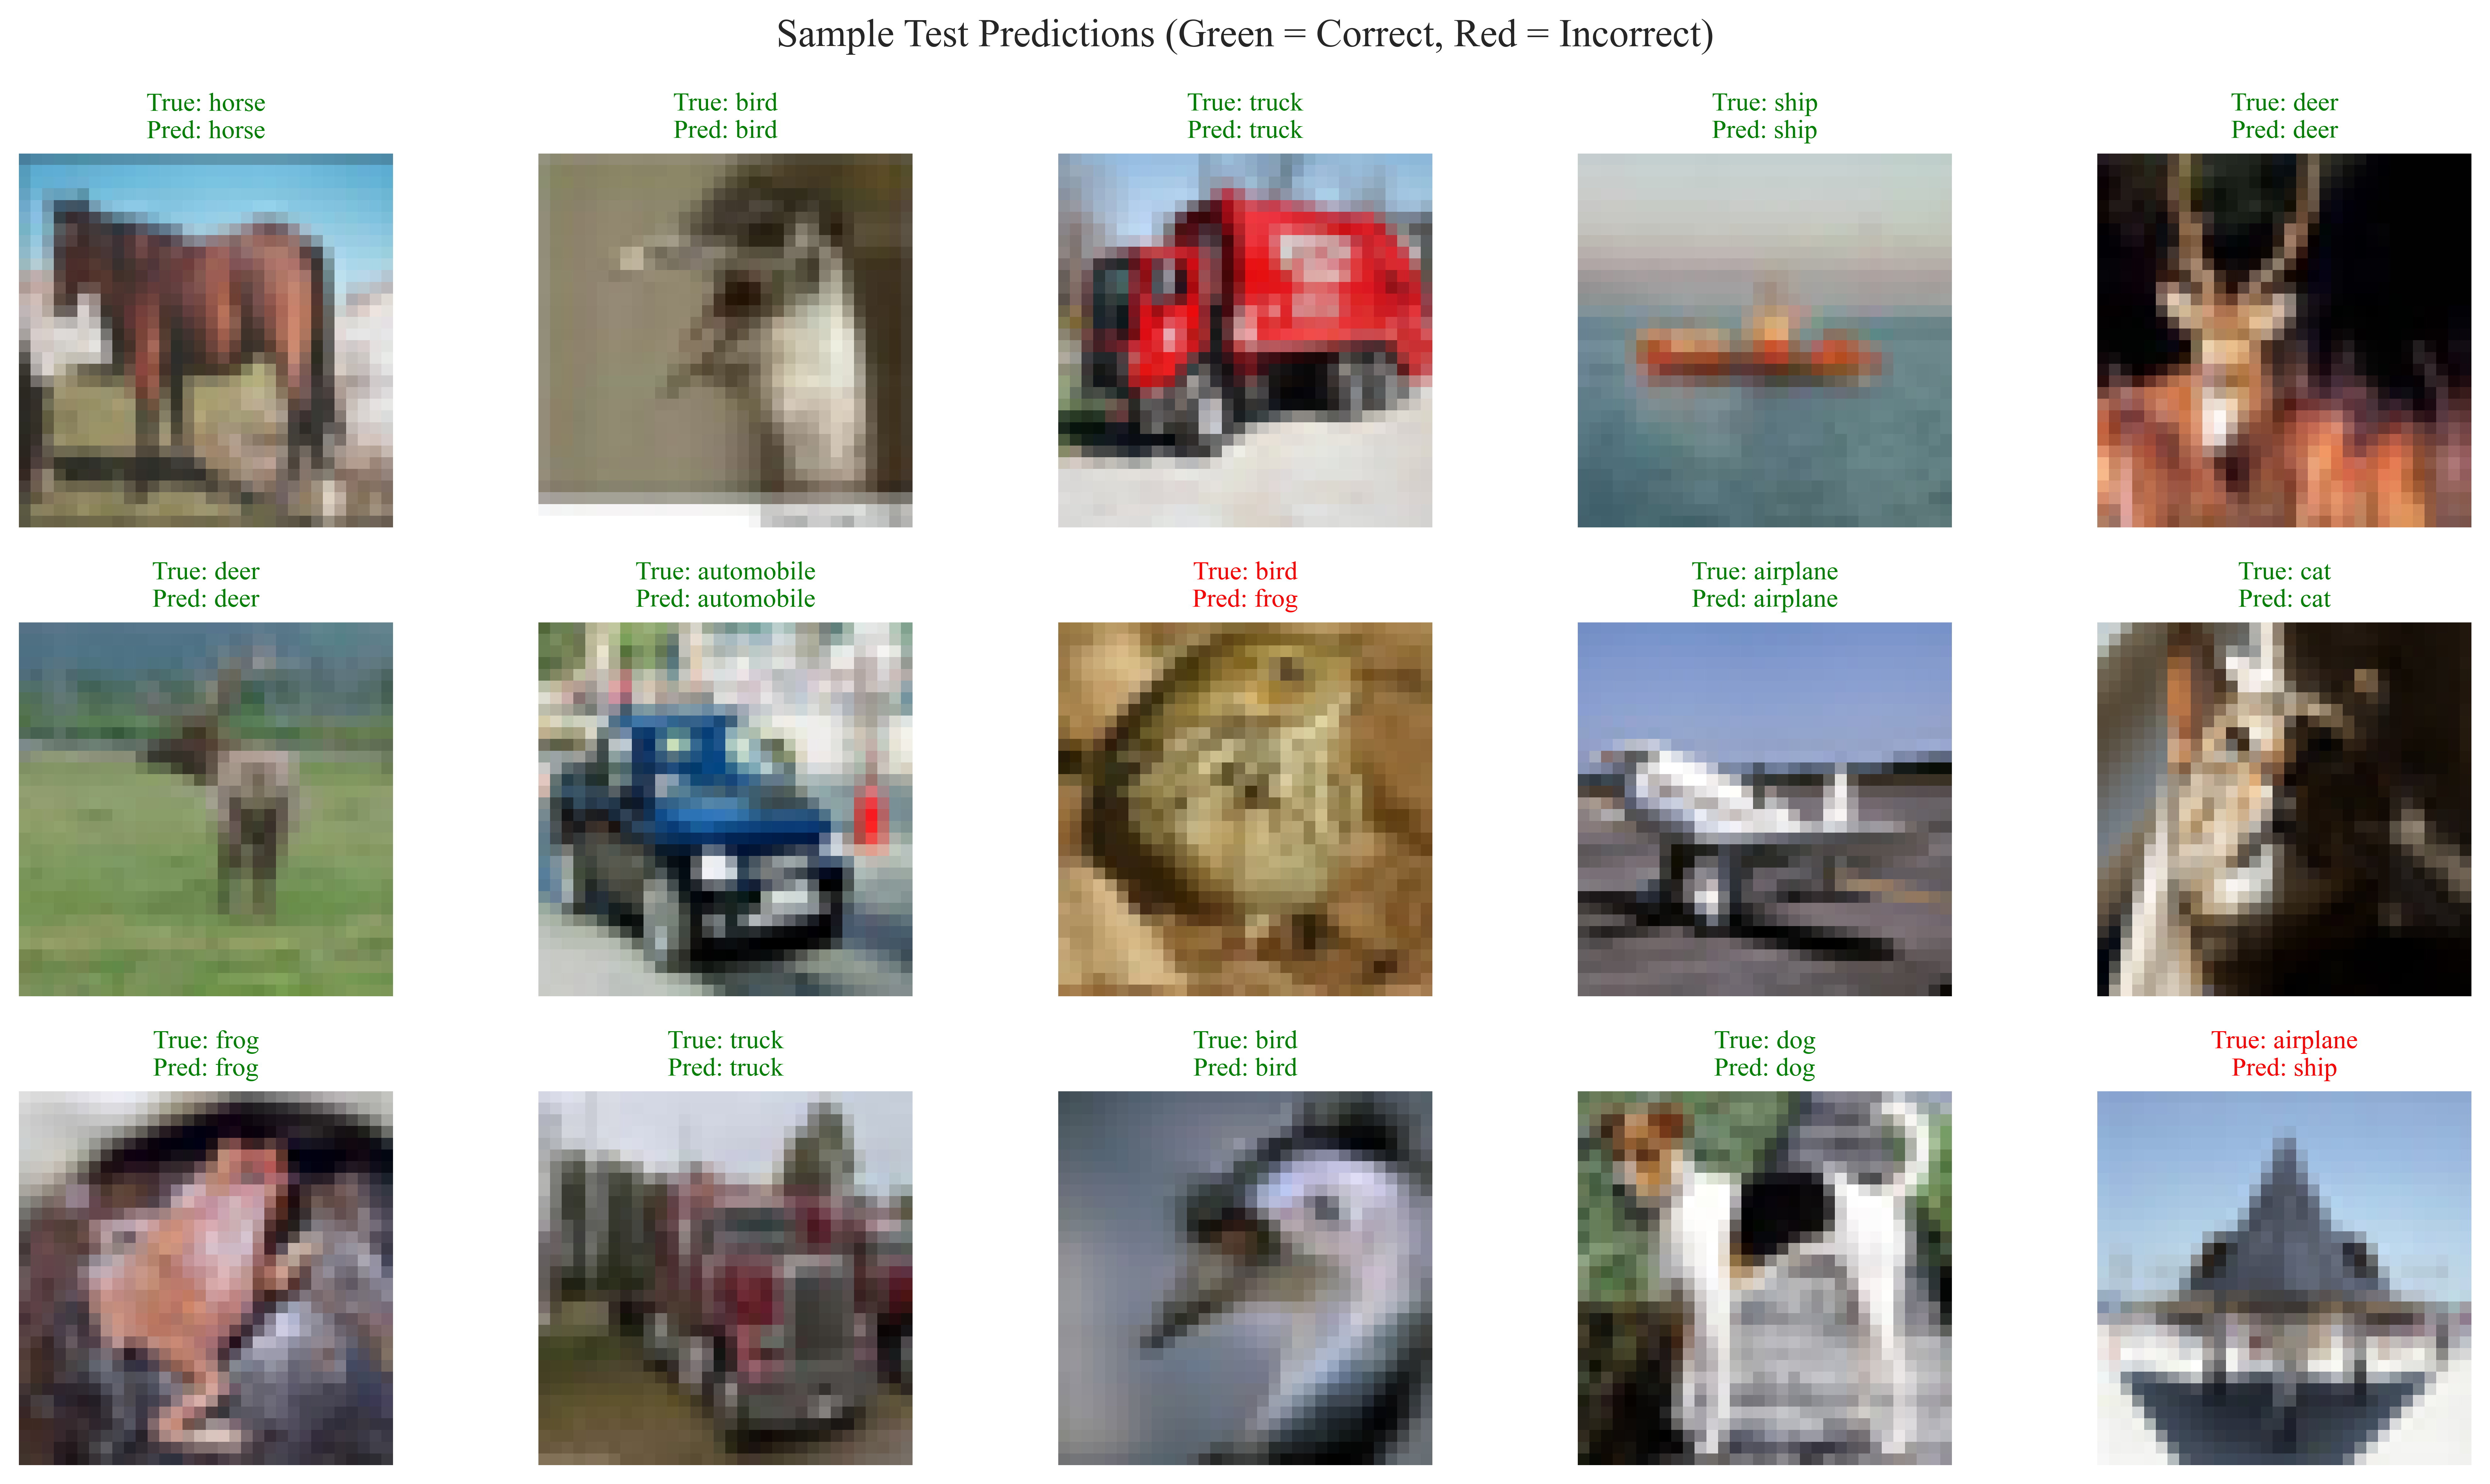

In [16]:
pred_fig, pred_axes = plt.subplots(3, 5, figsize=(14, 8))
indices = np.random.choice(len(x_test), 15, replace=False)

for i, idx in enumerate(indices):
    current_axis = pred_axes.flatten()[i]
    current_axis.imshow(x_test[idx])
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    current_axis.set_title(f"True: {true_label}\nPred: {pred_label}",
                            color=color, fontsize=10, fontweight='bold', fontname='Times New Roman')
    current_axis.axis('off')

pred_fig.suptitle("Sample Test Predictions (Green = Correct, Red = Incorrect)",
                   fontsize=15, fontweight='bold', fontname='Times New Roman')
plt.tight_layout()

plt.savefig(
    "sample_predictions.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 11. Visualizing Intermediate Feature Maps

Extract outputs from the intermediate convolutional layers to observe how the CNN progressively learns hierarchical representations — early layers capture edges/textures, deeper layers capture more abstract/complex patterns.


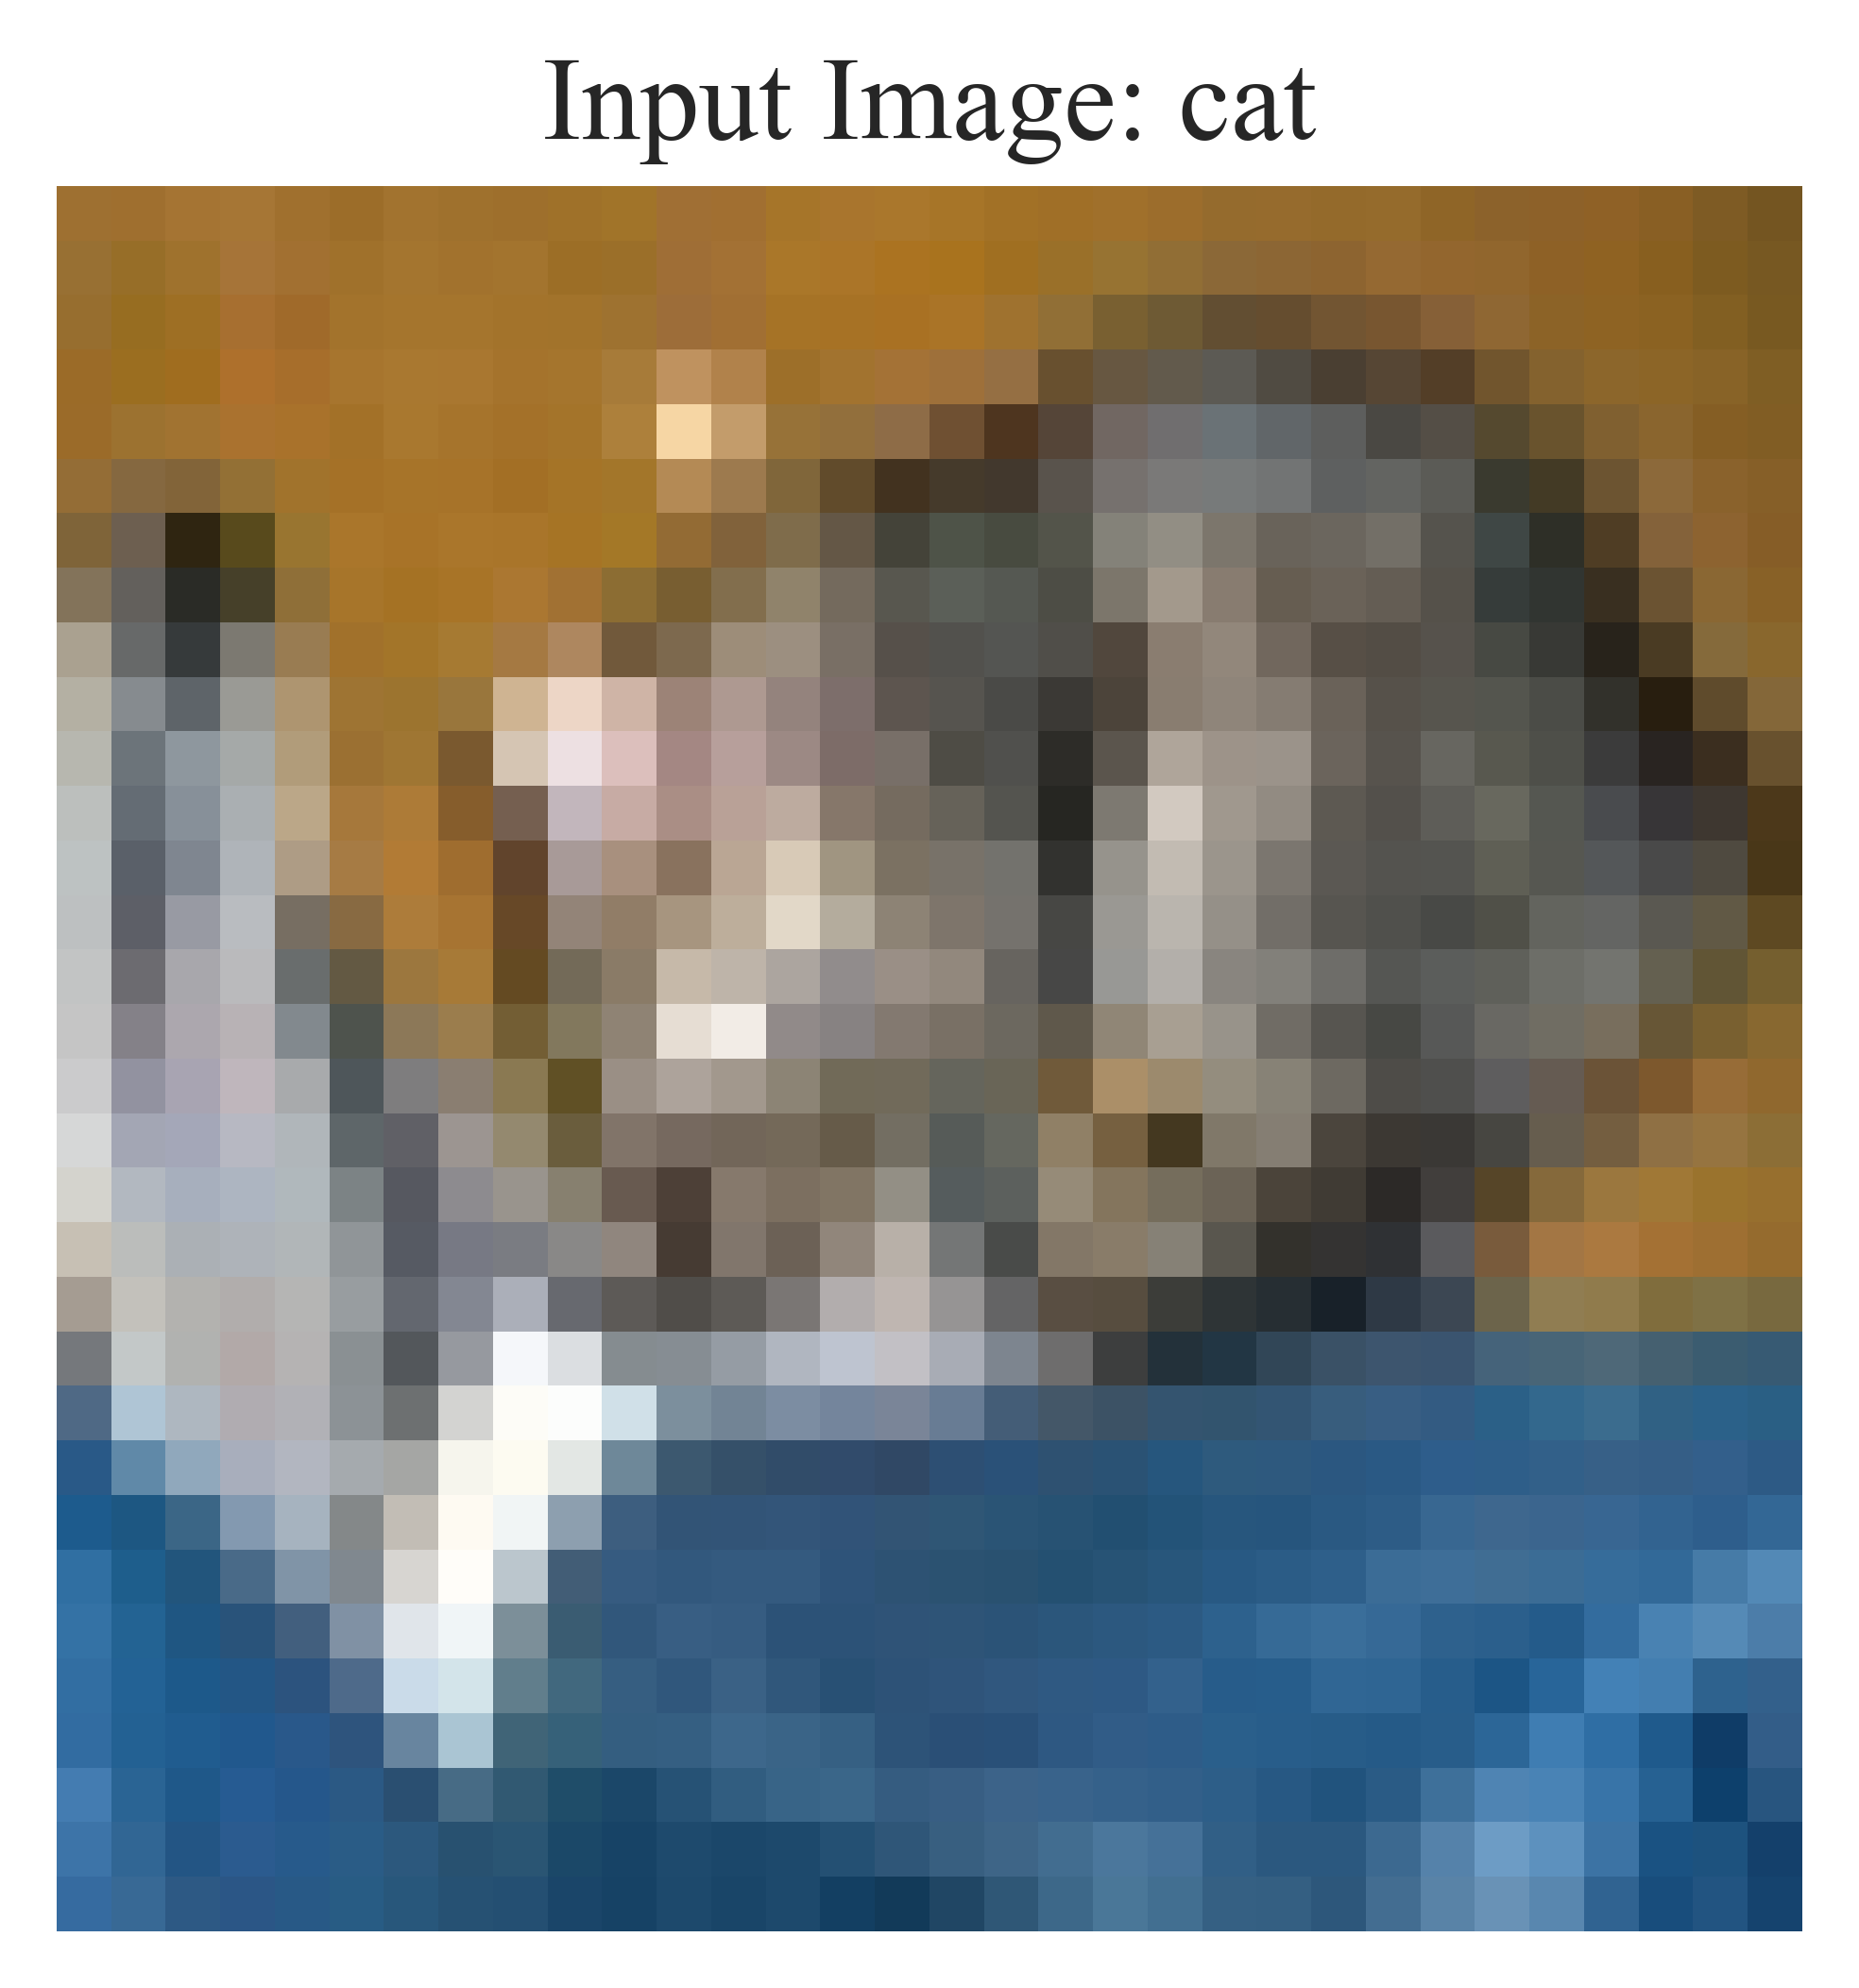

In [17]:
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name]
layer_outputs = [model.get_layer(name).output for name in conv_layer_names]
activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

sample_img = x_test[0:1]

plt.figure(figsize=(4, 4))
plt.imshow(x_test[0])
plt.title(f"Input Image: {class_names[y_true[0]]}", **title_style)
plt.axis('off')

plt.savefig(
    "feature_map_input_image.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

activations = activation_model.predict(sample_img, verbose=0)


Layer 'conv1' output shape: (1, 32, 32, 32)


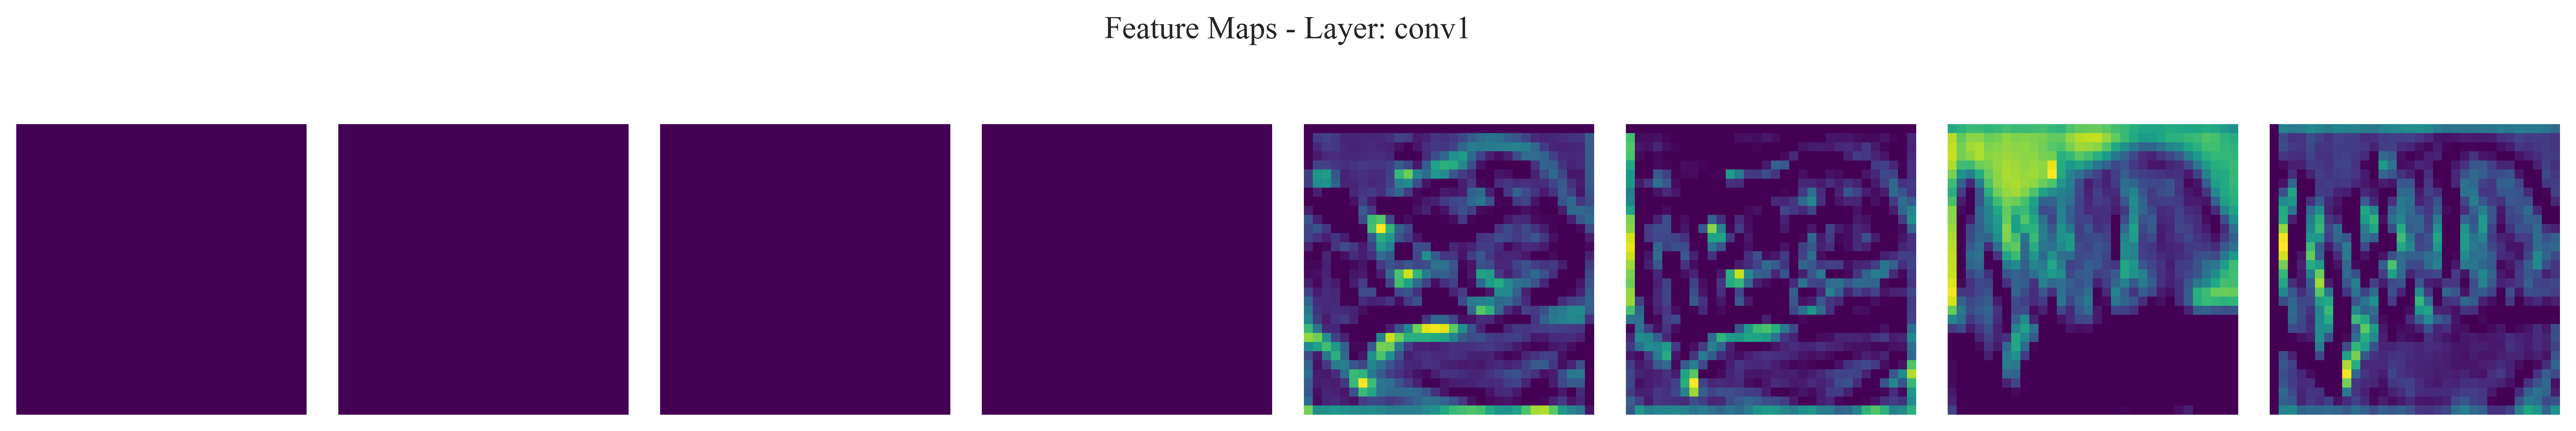

Layer 'conv2' output shape: (1, 32, 32, 32)


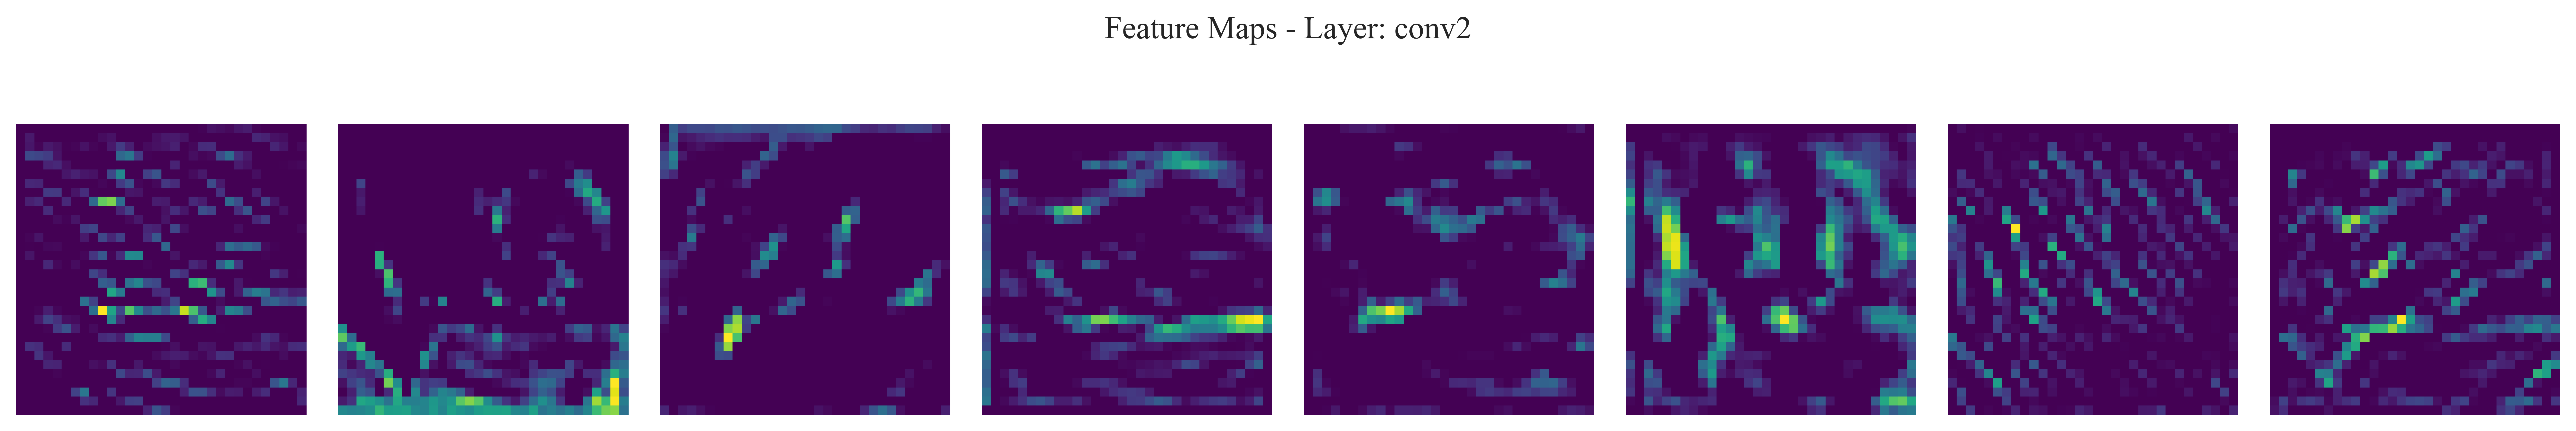

Layer 'conv3' output shape: (1, 16, 16, 64)


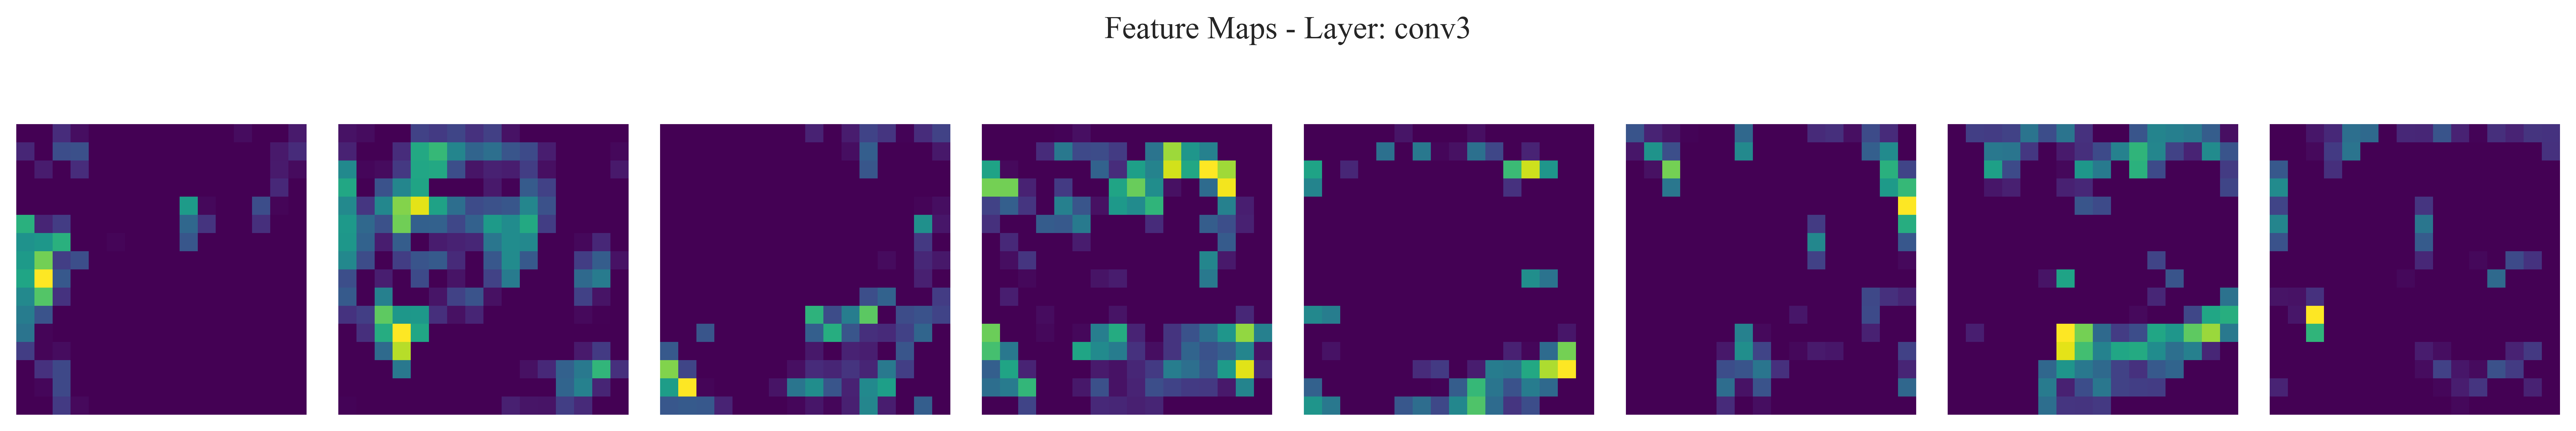

Layer 'conv4' output shape: (1, 16, 16, 64)


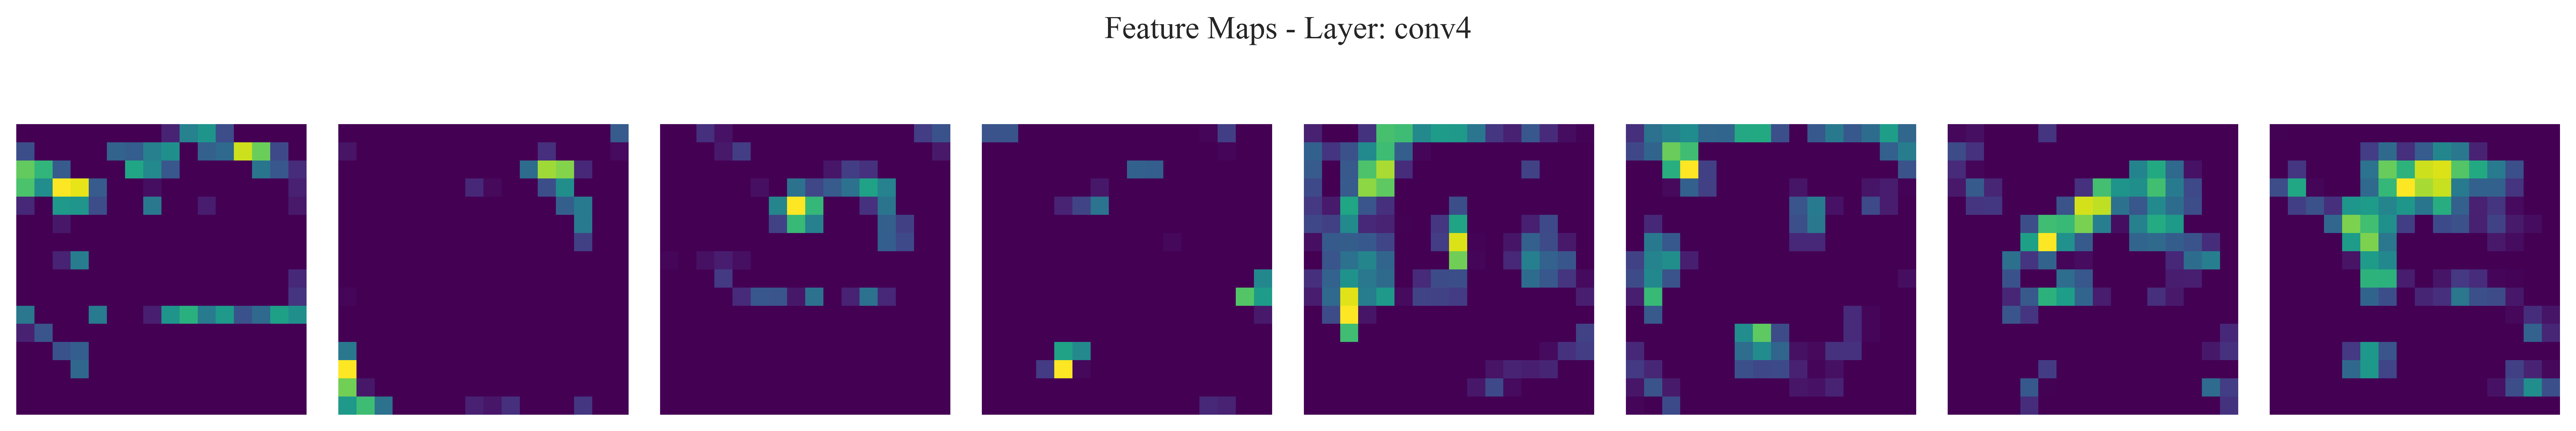

Layer 'conv5' output shape: (1, 8, 8, 128)


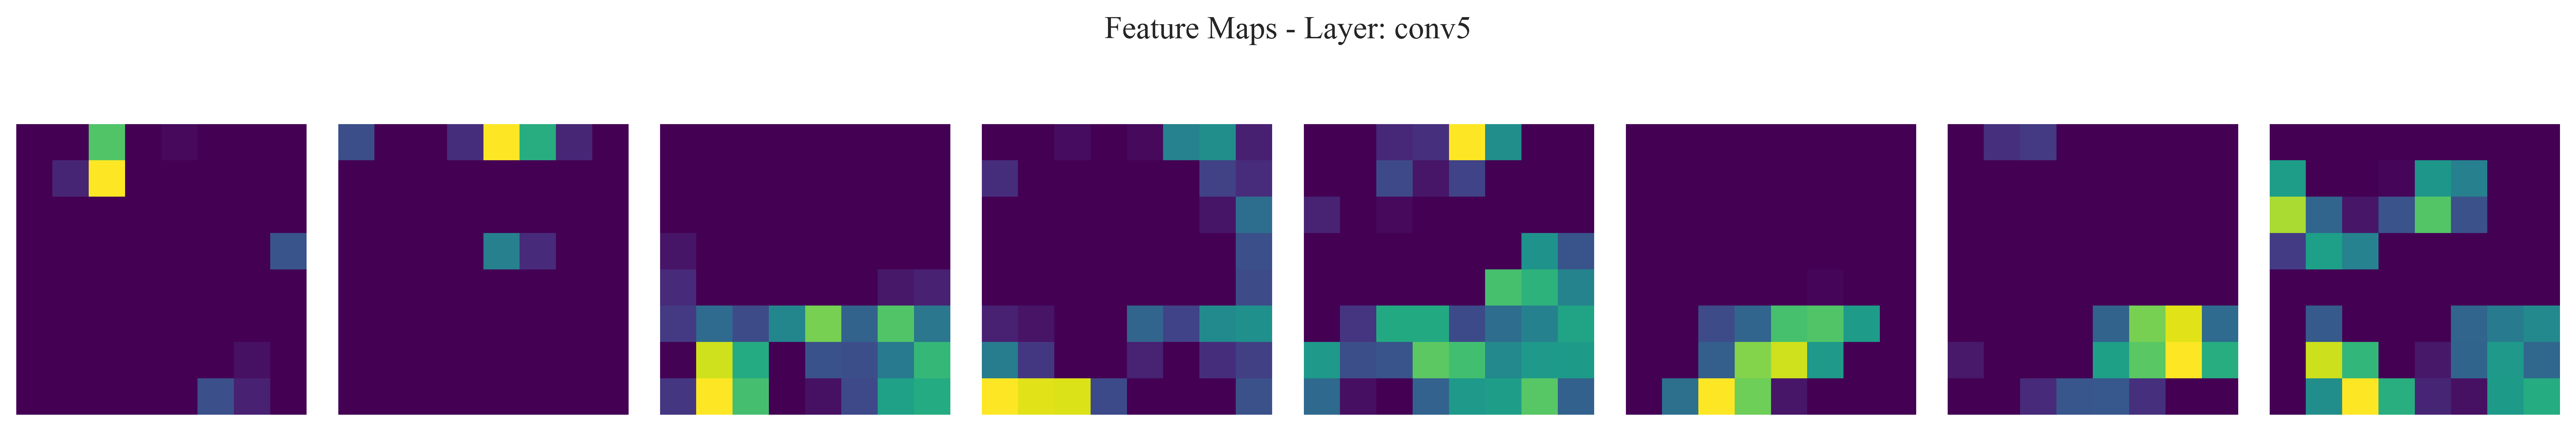

In [18]:
def plot_feature_maps(activation, layer_name, num_maps=8):
    num_maps = min(num_maps, activation.shape[-1])
    fmap_fig, fmap_axes = plt.subplots(1, num_maps, figsize=(num_maps * 2, 2.5))

    for i in range(num_maps):
        fmap_axes[i].imshow(activation[0, :, :, i], cmap='viridis')
        fmap_axes[i].axis('off')

    fmap_fig.suptitle(f"Feature Maps - Layer: {layer_name}", y=1.05,
                       fontsize=14, fontweight='bold', fontname='Times New Roman')
    fmap_fig.tight_layout()

    fmap_fig.savefig(
        f"feature_maps_{layer_name}.eps",
        format='eps',
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()
    plt.close(fmap_fig)

for name, activation in zip(conv_layer_names, activations):
    print(f"Layer '{name}' output shape: {activation.shape}")
    plot_feature_maps(activation, name, num_maps=8)

**Observation:** Feature maps from early convolutional layers (e.g., `conv1`, `conv2`) tend to highlight low-level features such as edges, corners, and color blobs, closely resembling the input image. Feature maps from deeper layers (e.g., `conv5`) become increasingly abstract and sparse, representing higher-level, more class-discriminative patterns — illustrating the hierarchical feature learning behavior of CNNs.

## 12. Comparing Pooling Strategies: Max Pooling vs Average Pooling

We build two smaller CNNs, identical except for the pooling operation, and compare their performance and behavior on a subset of the data for a quick comparison (to keep training time reasonable within this experiment).


In [19]:
def build_small_cnn(pooling_type='max'):
    small_inputs = keras.Input(shape=(32, 32, 3))
    PoolLayer = layers.MaxPooling2D if pooling_type == 'max' else layers.AveragePooling2D

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(small_inputs)
    x = PoolLayer(pool_size=(2, 2))(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = PoolLayer(pool_size=(2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    small_outputs = layers.Dense(10, activation='softmax')(x)

    small_model = keras.Model(inputs=small_inputs, outputs=small_outputs, name=f"CNN_{pooling_type}_pool")
    small_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return small_model

# Use a subset for a quick, fair comparison
subset = 10000
results = {}

for pool_type in ['max', 'average']:
    print(f"\n--- Training with {pool_type.upper()} pooling ---")
    m = build_small_cnn(pool_type)
    h = m.fit(x_train_final[:subset], y_train_final[:subset],
              validation_data=(x_val, y_val_cat),
              epochs=8, batch_size=64, verbose=0)
    test_loss, test_acc = m.evaluate(x_test, y_test_cat, verbose=0)
    results[pool_type] = {'history': h, 'test_acc': test_acc, 'test_loss': test_loss}
    print(f"{pool_type.capitalize()} Pooling -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")



--- Training with MAX pooling ---
Max Pooling -> Test Accuracy: 0.5648, Test Loss: 1.2118

--- Training with AVERAGE pooling ---
Average Pooling -> Test Accuracy: 0.5444, Test Loss: 1.2625


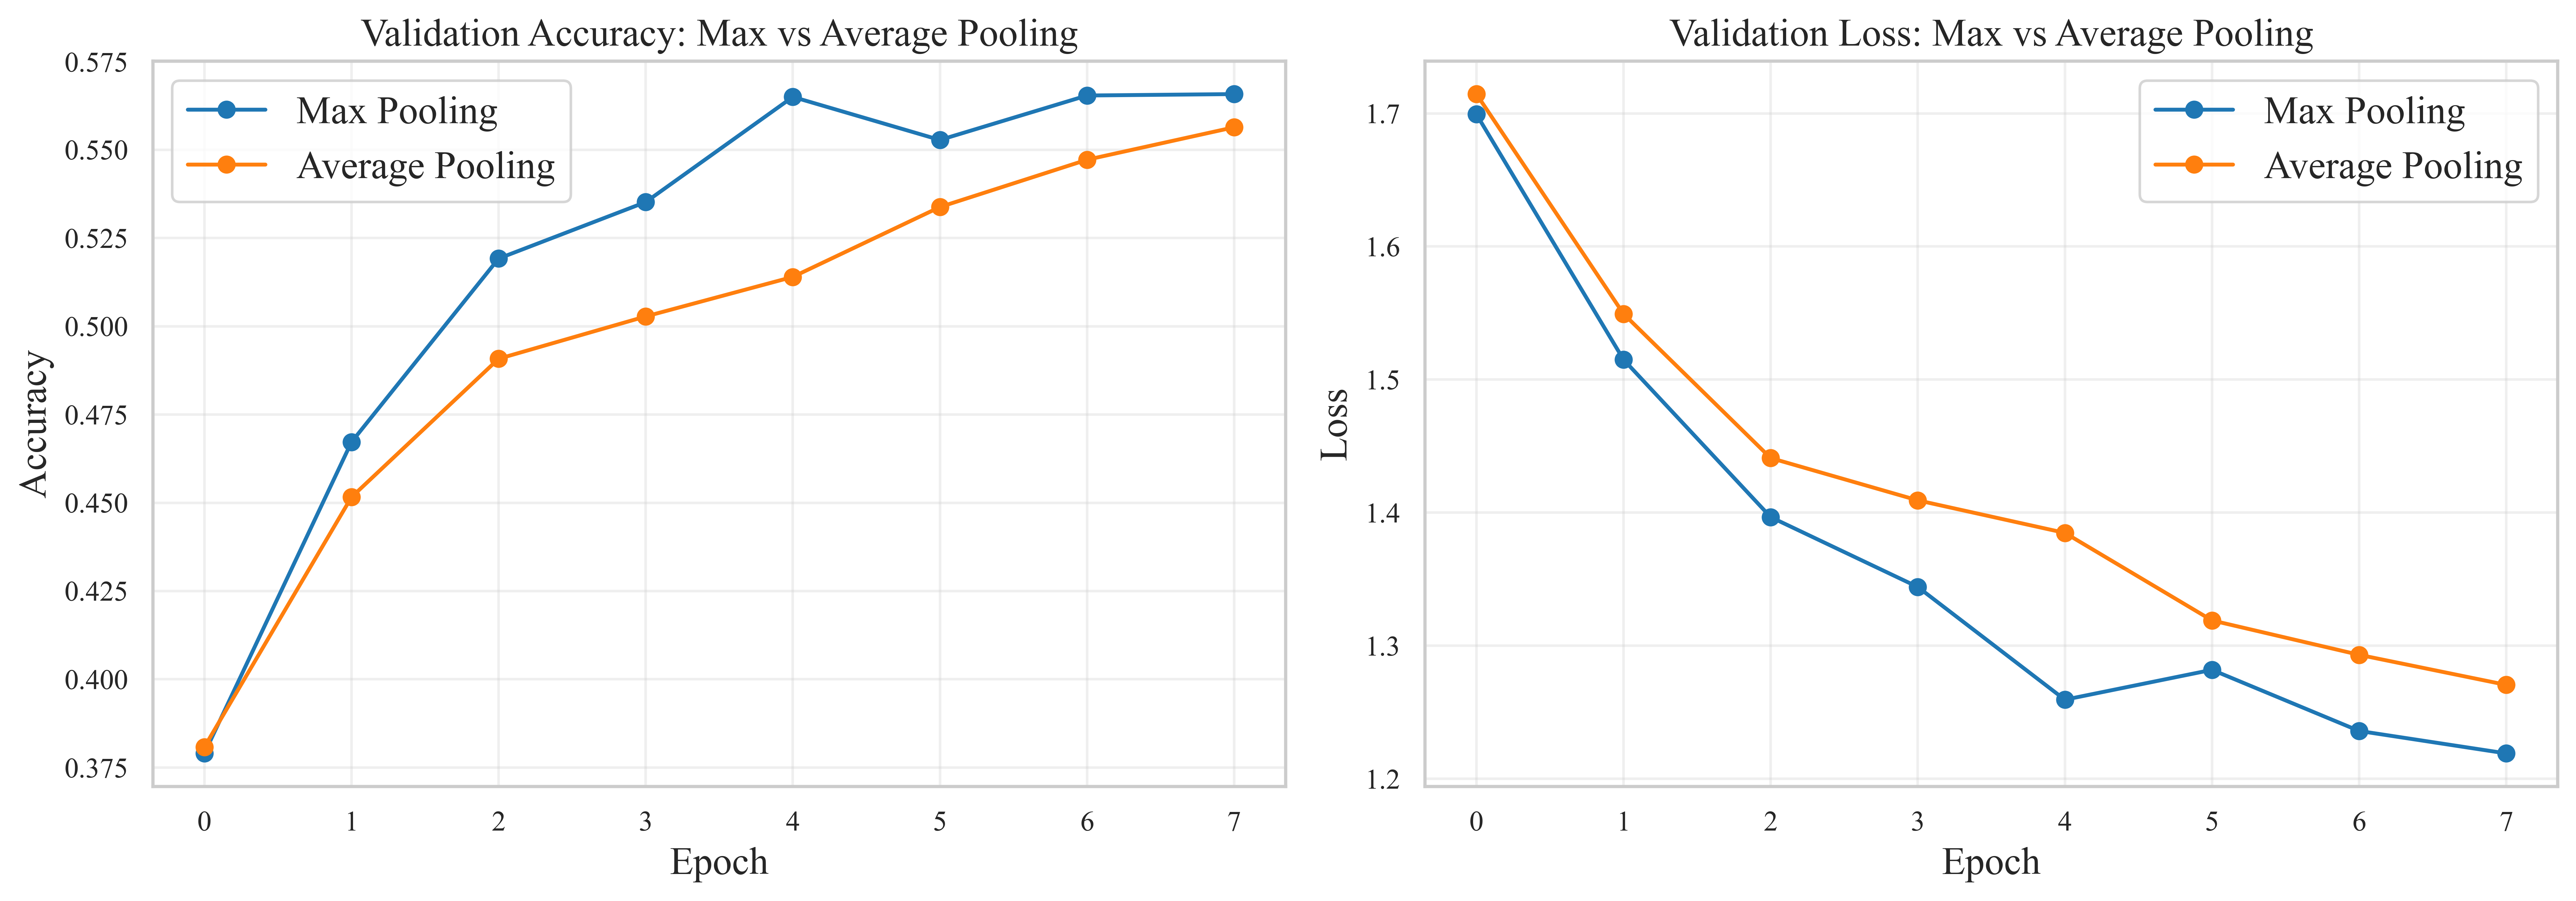


Summary:
Max Pooling -> Test Accuracy: 0.5648
Average Pooling -> Test Accuracy: 0.5444


In [20]:
pool_fig, pool_axes = plt.subplots(1, 2, figsize=(14, 5))

acc_axis = pool_axes[0]
loss_axis = pool_axes[1]

for pool_type in results:
    acc_axis.plot(results[pool_type]['history'].history['val_accuracy'],
                  label=f'{pool_type.capitalize()} Pooling', marker='o')
    loss_axis.plot(results[pool_type]['history'].history['val_loss'],
                   label=f'{pool_type.capitalize()} Pooling', marker='o')

acc_axis.set_title('Validation Accuracy: Max vs Average Pooling', **title_style)
acc_axis.set_xlabel('Epoch', **label_style)
acc_axis.set_ylabel('Accuracy', **label_style)
acc_legend = acc_axis.legend(prop=legend_style)
format_axis_ticks(acc_axis)
format_legend_text(acc_legend)
acc_axis.grid(alpha=0.3)

loss_axis.set_title('Validation Loss: Max vs Average Pooling', **title_style)
loss_axis.set_xlabel('Epoch', **label_style)
loss_axis.set_ylabel('Loss', **label_style)
loss_legend = loss_axis.legend(prop=legend_style)
format_axis_ticks(loss_axis)
format_legend_text(loss_legend)
loss_axis.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "pooling_comparison.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print("\nSummary:")
for pool_type in results:
    print(f"{pool_type.capitalize()} Pooling -> Test Accuracy: {results[pool_type]['test_acc']:.4f}")


**Observation:** Max Pooling typically preserves the most salient/dominant features (e.g., strong edges) by picking the maximum activation in each window, which often makes it more effective for classification tasks involving distinctive object features. Average Pooling smooths the feature map by averaging activations, which can retain more background/contextual information but may dilute strong discriminative signals. In most image classification benchmarks (including CIFAR-10), Max Pooling tends to converge faster and yield comparable or better accuracy.

## 13. Effect of Hyperparameters — Quick Experiment

We vary a single hyperparameter (batch size) while keeping others constant, training briefly on a subset, to observe its effect on convergence.



--- Training with batch_size=32 ---
Batch size 32 -> Test Accuracy: 0.5957

--- Training with batch_size=128 ---


Batch size 128 -> Test Accuracy: 0.5383


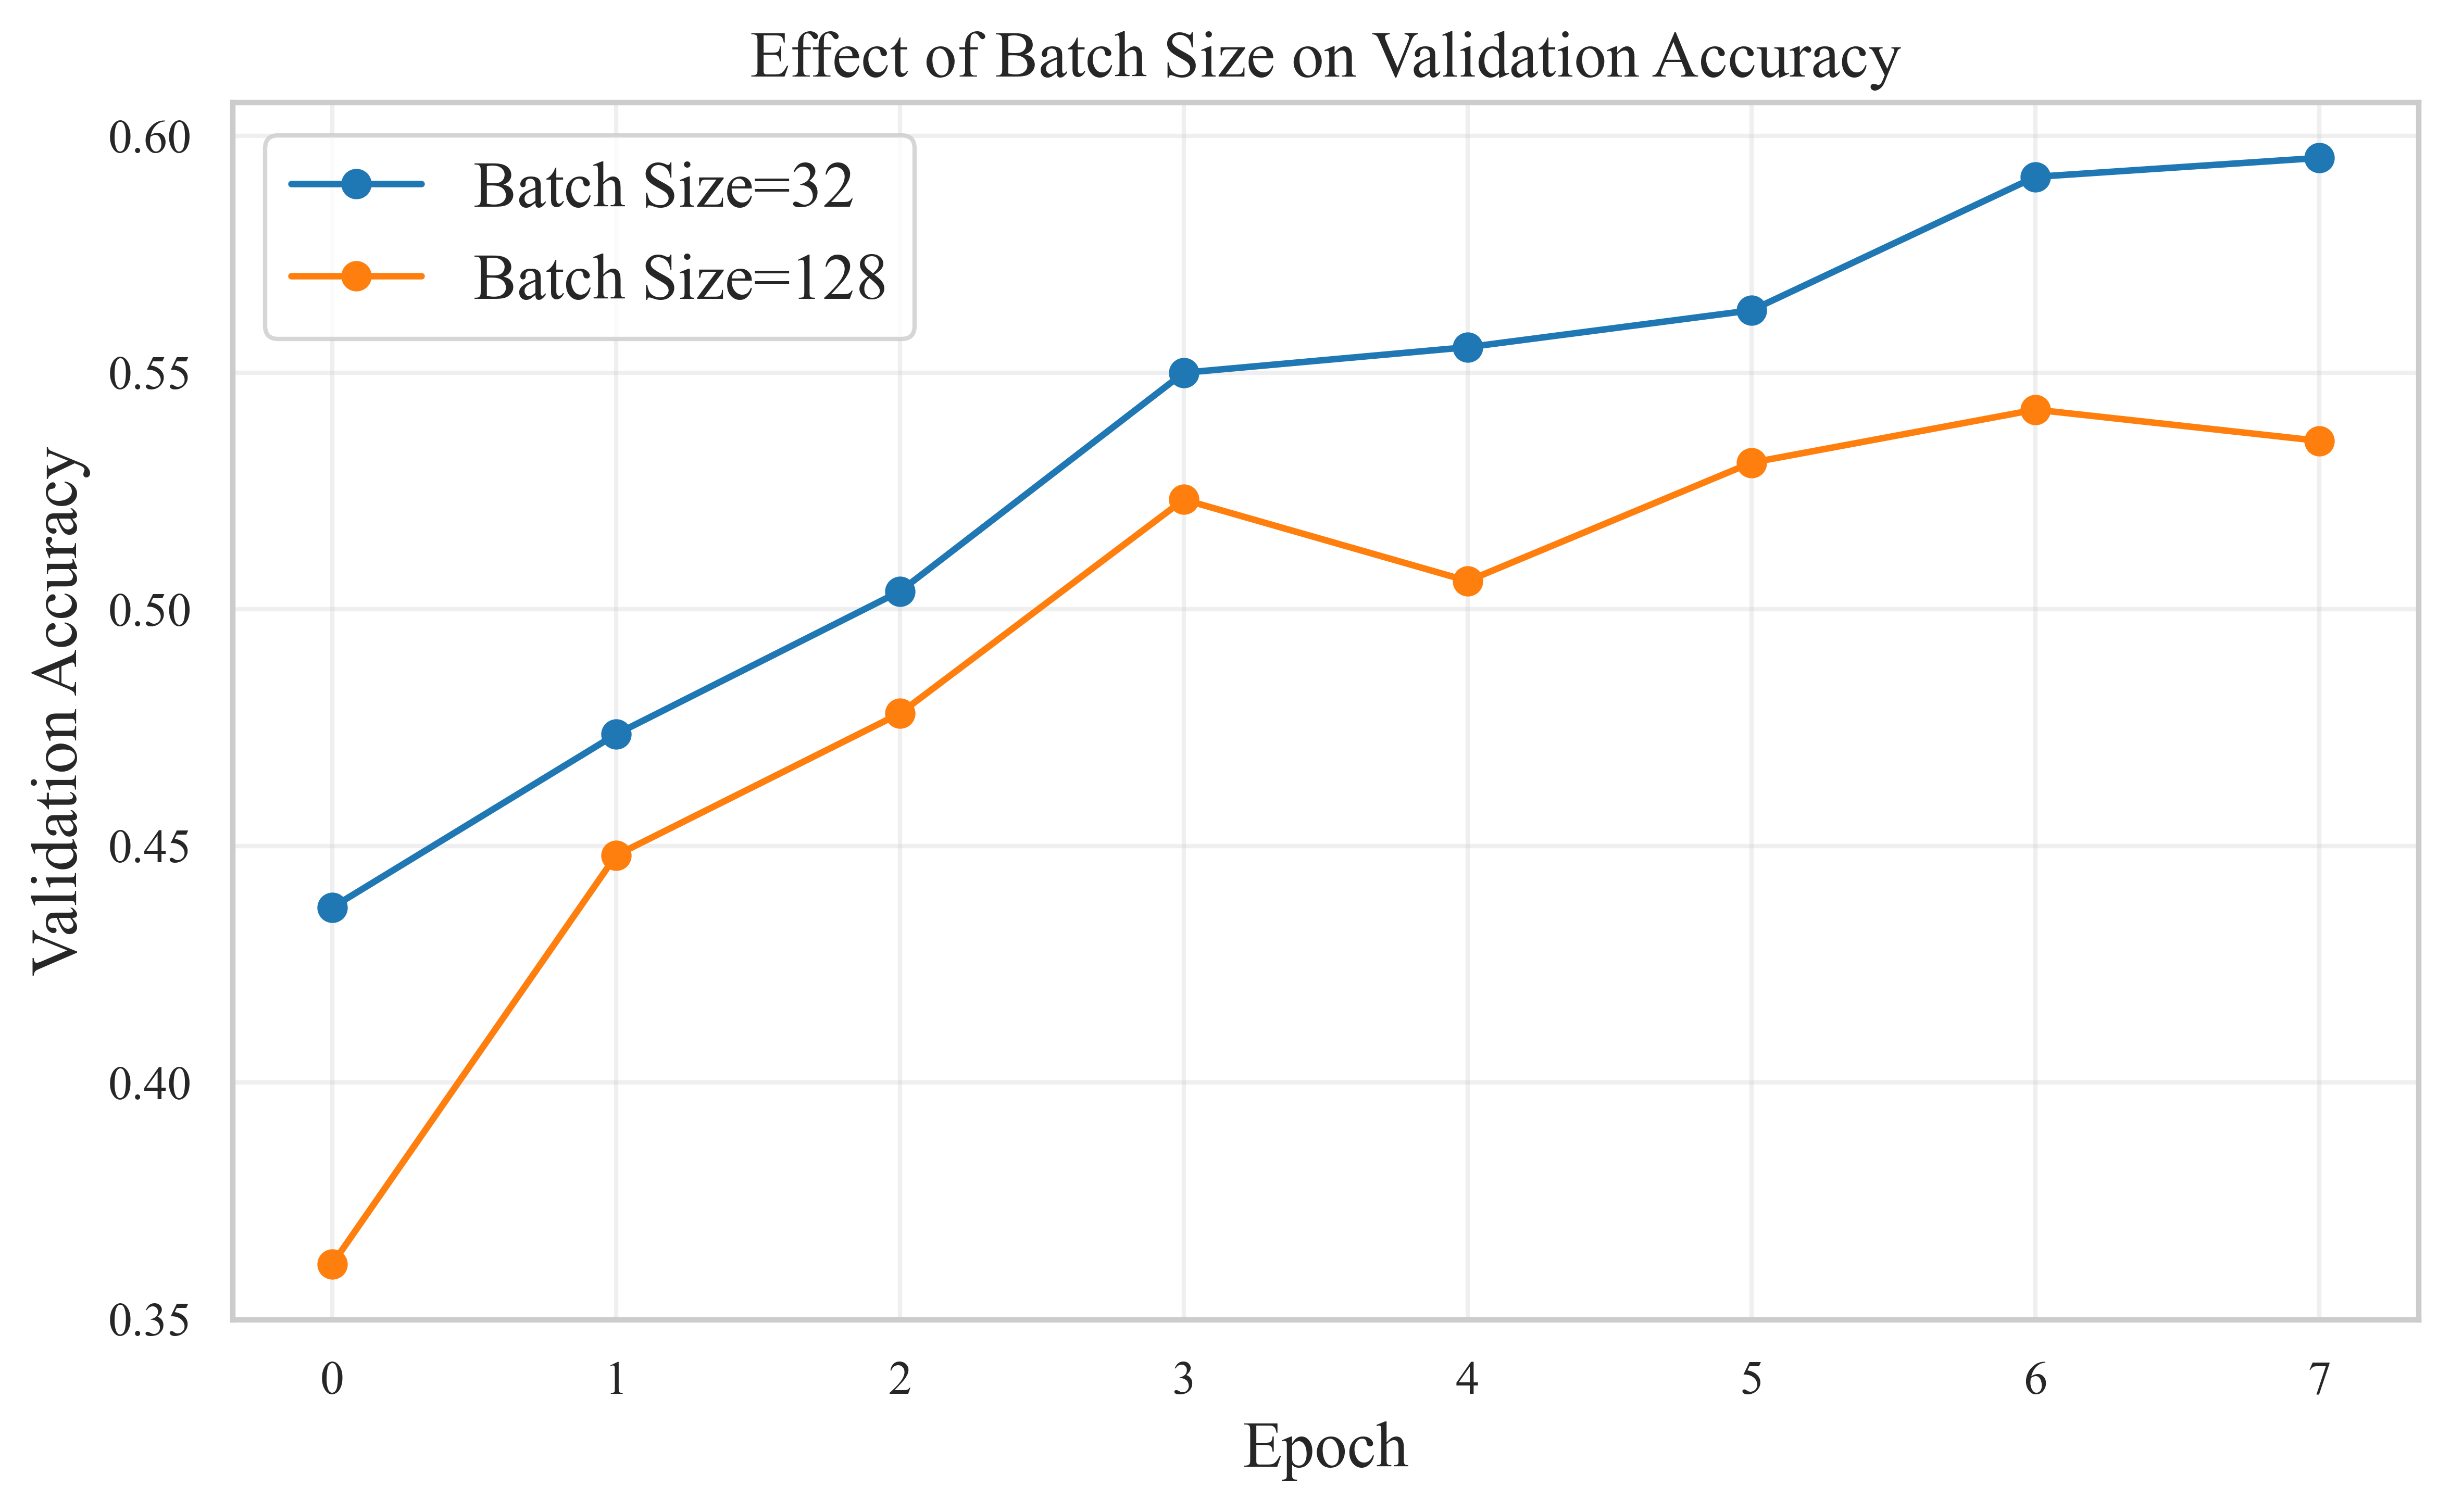

In [21]:
batch_sizes = [32, 128]
bs_results = {}

for bs in batch_sizes:
    print(f"\n--- Training with batch_size={bs} ---")
    m = build_small_cnn('max')
    h = m.fit(x_train_final[:subset], y_train_final[:subset],
              validation_data=(x_val, y_val_cat),
              epochs=8, batch_size=bs, verbose=0)
    test_loss, test_acc = m.evaluate(x_test, y_test_cat, verbose=0)
    bs_results[bs] = {'history': h, 'test_acc': test_acc}
    print(f"Batch size {bs} -> Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(8, 5))
bs_axis = plt.gca()

for bs in bs_results:
    bs_axis.plot(bs_results[bs]['history'].history['val_accuracy'],
                 label=f'Batch Size={bs}', marker='o')

bs_axis.set_title('Effect of Batch Size on Validation Accuracy', **title_style)
bs_axis.set_xlabel('Epoch', **label_style)
bs_axis.set_ylabel('Validation Accuracy', **label_style)
bs_legend = bs_axis.legend(prop=legend_style)
format_axis_ticks(bs_axis)
format_legend_text(bs_legend)
bs_axis.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "batch_size_comparison.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 14. Conclusion

- A CNN with three convolutional blocks (Conv2D + BatchNorm + MaxPooling) was successfully designed, trained, and evaluated on the CIFAR-10 dataset.
- The convolutional layers progressively extract features from low-level edges/textures (early layers) to abstract, class-discriminative patterns (deeper layers), as confirmed by feature map visualization.
- Model performance was quantified using accuracy, precision, recall, F1-score, the confusion matrix, and a detailed classification report.
- Max Pooling and Average Pooling were compared, showing how the choice of pooling strategy affects feature retention and model performance.
- Hyperparameters such as batch size, kernel size, stride, padding, number of filters, and optimizer choice were shown to meaningfully influence training dynamics and final accuracy.
- This experiment provided practical, hands-on experience in applying deep learning and CNN architecture design principles to a real-world computer vision classification problem.


## 15. Download All EPS Plots (600 DPI, Times New Roman) as a ZIP

All figures generated above were saved as individual `.eps` files at 600 DPI with Times New Roman formatting. This final cell collects all of them into a single ZIP archive and triggers a download (Colab only).


> **Note on file size:** Plots built from `imshow()` (sample images, feature maps, sample predictions) embed raster image data uncompressed in EPS, so at 600 DPI these individual files can be tens of MB each and the full ZIP can reach several hundred MB. Line/bar/heatmap-style plots (training curves, confusion matrix, class distribution, pooling comparison) stay small (tens of KB to a few MB). If ZIP size becomes an issue in Colab, consider lowering `dpi` specifically for the image-heavy plots, or export those as high-resolution PNG instead of EPS.

In [22]:
import glob
import zipfile

eps_files = glob.glob("*.eps")
print(f"Found {len(eps_files)} EPS files:")
for eps_file in eps_files:
    print(" -", eps_file)

with zipfile.ZipFile("cnn_cifar10_eps_plots.zip", "w") as zip_file:
    for eps_file in eps_files:
        zip_file.write(eps_file)

print("\nZIP archive created: cnn_cifar10_eps_plots.zip")

try:
    from google.colab import files
    files.download("cnn_cifar10_eps_plots.zip")
except ImportError:
    print("Not running in Google Colab — the ZIP file is saved in the current working directory. "
          "Download it manually from the file browser (left sidebar in Jupyter) if needed.")


Found 13 EPS files:
 - feature_maps_conv2.eps
 - feature_maps_conv4.eps
 - sample_images.eps
 - sample_predictions.eps
 - feature_maps_conv3.eps
 - training_curves.eps
 - feature_maps_conv5.eps
 - feature_map_input_image.eps
 - pooling_comparison.eps
 - confusion_matrix.eps
 - batch_size_comparison.eps
 - feature_maps_conv1.eps
 - class_distribution.eps

ZIP archive created: cnn_cifar10_eps_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>